In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import mne
import pickle
import yaml
from tabulate import tabulate
import pandas as pd
from mne.time_frequency import psd_array_multitaper
from typing import Dict, List

from gaitmod.utils.file_reader import MatFileReader
from gaitmod.utils.data_processor import DataProcessor
from gaitmod.viz import Visualise
from gaitmod.utils.feature_extractor import FeatureExtractor
from gaitmod.utils.utils import *

2026-03-09 05:24:38.462096: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-09 05:24:38.481994: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-09 05:24:38.482025: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Loading the data

In [2]:
config = load_config('gaitmod/configs/data_preprocessing.yaml')

In [3]:
# Handle multiple patients with nested directories.
root_directory = config['data']['root_directory']
subject_id = config['data']['subject_id']
# subject_id = ['PW_HK59']

mat_reader = MatFileReader(root_directory, subject_id)  # adjust the number of workers for parallelism later.

# Read all data from nested folders of multiple patients and sessions
data = mat_reader.read_data(max_workers=1)
n_subjects = len(data)

print(f"Number of subjects: {n_subjects}")

Loading: ../../../data/orabem/Gait_Modulation_Prediction_DATA/PW_HK59/26-10-22/MAT/walking_sync_updated_1.mat
Loading: ../../../data/orabem/Gait_Modulation_Prediction_DATA/PW_HK59/26-10-22/MAT/walking_sync_updated_2.mat
Loading: ../../../data/orabem/Gait_Modulation_Prediction_DATA/PW_HK59/26-10-22/MAT/walking_sync_updated_3.mat
Loading: ../../../data/orabem/Gait_Modulation_Prediction_DATA/PW_EM59/21-07-23/MAT/walking_sync_updated_3.mat


Loading: ../../../data/orabem/Gait_Modulation_Prediction_DATA/PW_EM59/21-07-23/MAT/walking_sync_updated_4.mat
Loading: ../../../data/orabem/Gait_Modulation_Prediction_DATA/PW_FH57/23-01-23/MAT/walking_sync_updated_1.mat
Loading: ../../../data/orabem/Gait_Modulation_Prediction_DATA/PW_FH57/23-01-23/MAT/walking_sync_updated_2.mat
Loading: ../../../data/orabem/Gait_Modulation_Prediction_DATA/PW_FH57/23-01-23/MAT/walking_sync_updated_3.mat
Loading: ../../../data/orabem/Gait_Modulation_Prediction_DATA/PW_FH57/23-01-23/MAT/walking_sync_updated_4.mat
Loading: ../../../data/orabem/Gait_Modulation_Prediction_DATA/PW_US68/20-12-22/MAT/walking_sync_updated_1.mat
Loading: ../../../data/orabem/Gait_Modulation_Prediction_DATA/PW_US68/20-12-22/MAT/walking_sync_updated_2.mat
Loading: ../../../data/orabem/Gait_Modulation_Prediction_DATA/PW_US68/20-12-22/MAT/walking_sync_updated_3.mat
Loading: ../../../data/orabem/Gait_Modulation_Prediction_DATA/PW_SN66/20-09-23/MAT/walking_sync_updated_1.mat
Loading: .

In [4]:
for patient, sessions in data.items():
    print(f"Patient: {patient}, Sessions: {list(sessions.keys())}")

Patient: PW_HK59, Sessions: ['walking_sync_updated_1', 'walking_sync_updated_2', 'walking_sync_updated_3']
Patient: PW_EM59, Sessions: ['walking_sync_updated_3', 'walking_sync_updated_4']
Patient: PW_FH57, Sessions: ['walking_sync_updated_1', 'walking_sync_updated_2', 'walking_sync_updated_3', 'walking_sync_updated_4']
Patient: PW_US68, Sessions: ['walking_sync_updated_1', 'walking_sync_updated_2', 'walking_sync_updated_3']
Patient: PW_SN66, Sessions: ['walking_sync_updated_1', 'walking_sync_updated_2']
Patient: PW_HZ58, Sessions: ['walking_sync_updated_3', 'walking_sync_updated_4', 'walking_sync_updated_6']
Patient: PW_SN61, Sessions: ['walking_sync_updated_1', 'walking_sync_updated_2', 'walking_sync_updated_3', 'walking_sync_updated_4']


In [5]:
valid_data_types = ['data_acc', 'data_EEG', 'data_EMG', 'data_giro', 'data_LFP']
data_type = 'data_LFP'

try:
    # Pick any subject/session to extract common meta data e.g. the first one
    first_subject = list(data.keys())[0]
    first_session = list(data[first_subject].keys())[0]
    first_data = data[first_subject][first_session]
    if data_type not in valid_data_types:
        raise ValueError("Invalid data type specified.")
except Exception as e:
    raise ValueError(f"Error processing data: {e}")

data_names = ['data_EEG', 'data_EMG', 'data_LFP', 'data_acc', 'data_giro', 'events_KIN', 'events_STEPS', 'filePath_2', 'hdr_EEG', 'hdr_EMG', 'hdr_IMU', 'hdr_LFP', 'pt', 'session']
if not np.all([dt in data_names for dt in first_data.keys()]):
    raise ValueError(f"Invalid data type found in the data.")

# Extract LFP meta data for subject/session
# lfp_metadata = DataProcessor.np_to_dict(first_data['hdr_LFP'])

lfp_metadata = first_data['hdr_LFP']
lfp_sfreq = lfp_metadata['Fs']
lfp_metadata

{'Fs': 250,
 'labels': array(['ZERO_THREE_LEFT', 'ONE_THREE_LEFT', 'ZERO_TWO_LEFT',
        'ZERO_THREE_RIGHT', 'ONE_THREE_RIGHT', 'ZERO_TWO_RIGHT'],
       dtype=object),
 'NumberOfChannels': 6,
 'chanunit': array(['µV', 'µV', 'µV', 'µV', 'µV', 'µV'], dtype='<U2'),
 'chantype': array(['LFP', 'LFP', 'LFP', 'LFP', 'LFP', 'LFP'], dtype='<U3')}

In [6]:
fig_save_path ='results/figures/processed_data'
os.makedirs(fig_save_path, exist_ok=True)

fix_chs_names = [
    'ZERO_THREE_LEFT',
    'ONE_THREE_LEFT',
    'ZERO_TWO_LEFT',
    'ZERO_THREE_RIGHT',
    'ONE_THREE_RIGHT',
    'ZERO_TWO_RIGHT'
]

new_events_order = [
    'trial_start', # importatnt to keep this as the first event
    'VA_start_walking',
    'mod_start',
    'VA_cross',
    'min_vel',
    'min_dist',
    'mod_end',
    'trial_stop' # important to keep this as the last event
]

key_map = {"label": "labels",
           "time": "times"}
        
DataProcessor.clean_data(data, 'data_LFP', key_map, new_events_order, lfp_sfreq, fix_chs_names)

subjects_lfp_data_dict, subjects_event_idx_dict, subjects_session_trial_mapping = DataProcessor.process_trials_and_events(data, 'data_LFP', lfp_sfreq, config, verbose=True)

ch_names = list(data[first_subject][first_session]['hdr_LFP']['labels'])
ch_names

Patient ID: PW_HK59
walking_sync_updated_1: 6 channels found
--------------------------------------------------
walking_sync_updated_2: 6 channels found
--------------------------------------------------
walking_sync_updated_3: 6 channels found
--------------------------------------------------
Patient ID: PW_EM59
walking_sync_updated_3: 6 channels found
--------------------------------------------------
walking_sync_updated_4: 6 channels found
--------------------------------------------------
Patient ID: PW_FH57
walking_sync_updated_1: 6 channels found
--------------------------------------------------
walking_sync_updated_2: 6 channels found
--------------------------------------------------
walking_sync_updated_3: 6 channels found
--------------------------------------------------
walking_sync_updated_4: 6 channels found
--------------------------------------------------
Patient ID: PW_US68
walking_sync_updated_1: 6 channels found
--------------------------------------------------


['ZERO_THREE_LEFT',
 'ONE_THREE_LEFT',
 'ZERO_TWO_LEFT',
 'ZERO_THREE_RIGHT',
 'ONE_THREE_RIGHT',
 'ZERO_TWO_RIGHT']

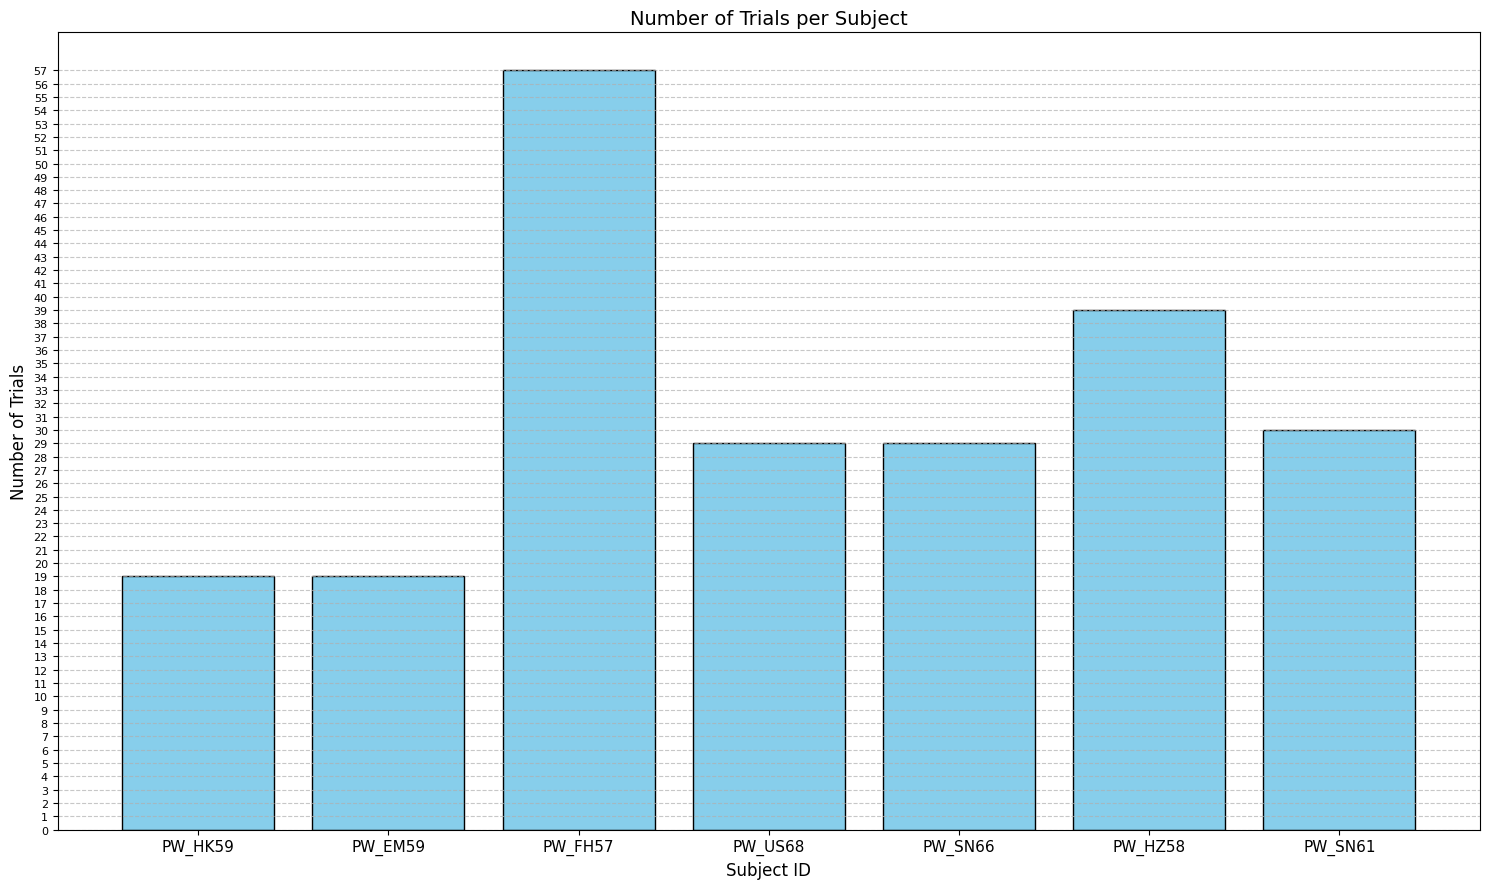

,subject_id,n_trials
0,PW_HK59,19
1,PW_EM59,19
2,PW_FH57,57
3,PW_US68,29
4,PW_SN66,29
5,PW_HZ58,39
6,PW_SN61,30


In [7]:
n_subjects = len(subjects_event_idx_dict)
n_trials_list = []
subjects_list = []

table_data = []
for subject_name, event_data in subjects_event_idx_dict.items():
    n_trials = event_data.shape[0]
    n_trials_list.append(n_trials)
    subjects_list.append(subject_name)
    table_data.append([subject_name, n_trials])
df_trial_counts = pd.DataFrame(table_data, columns=["subject_id", "n_trials"])

Visualise.plot_trial_counts(df_trial_counts, fig_save_path, fig_name='trials_per_subject')

df_trial_counts

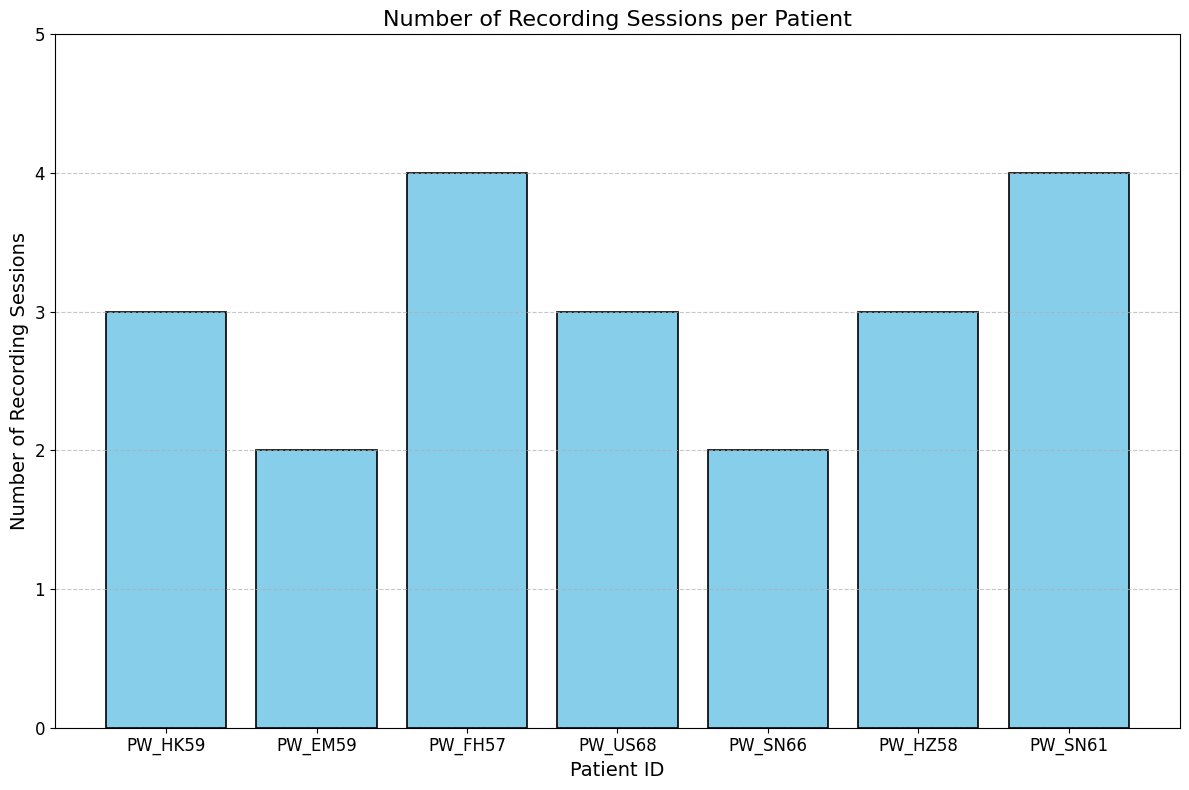

,patient_id,n_essions
0,PW_HK59,3
1,PW_EM59,2
2,PW_FH57,4
3,PW_US68,3
4,PW_SN66,2
5,PW_HZ58,3
6,PW_SN61,4


In [8]:
# Count the number of recording sessions per patient
df_session_counts = pd.DataFrame(
    [(patient, len(sessions)) for patient, sessions in data.items()],
    columns=["patient_id", "n_essions"]
)
# Call the function to plot the session counts
Visualise.plot_session_counts(df_session_counts, fig_save_path, fig_name='session_counts')

df_session_counts

In [9]:
subjects_lfp_data_dict['PW_HK59'][0].shape

(6, 2605)

In [10]:
subjects_event_idx_dict['PW_HK59'], subjects_event_idx_dict['PW_HK59'].shape

(array([[   0,  452,  620, 1035, 1163, 1218, 1350, 2605],
        [   0,  621,  988, 1214, 1040, 1353, 1138, 2355],
        [   0,  446,  733,  863, 1060, 1028, 1703, 2265],
        [   0,  575,  920, 1377, 2120, 1613, 3205, 4165],
        [   0,  503,  645, 1139, 1105, 1333, 1688, 2500],
        [   0,  653,  875, 1911, 1975, 2270, 2250, 3985],
        [   0,  477,  775,  880,  898, 1038, 1245, 2970],
        [   0,  559,  910, 1264, 1663, 1480, 2248, 4415],
        [   0,  581,  888, 1368, 1265, 1663, 2125, 3890],
        [   0,  541, 1060, 1826, 1955, 2325, 2880, 4510],
        [   0,  579,  723, 1106, 1105, 1260, 1305, 2430],
        [   0,  462,  665,  875,  900, 1035, 1448, 2530],
        [   0,  648, 1198, 1309, 1840, 1460, 2398, 3375],
        [   0,  462,  647, 1125,  992, 1375, 1790, 5155],
        [   0,  647,  882, 1235, 1007, 1420, 1320, 2885],
        [   0,  601,  857, 1350, 1375, 1760, 1717, 7550],
        [   0,  595,  615, 1184,  660, 1292,  760, 2320],
        [   0,

In [11]:
subjects_session_trial_mapping['PW_HK59']

{'walking_sync_updated_1': [0, 1, 2, 3, 4],
 'walking_sync_updated_2': [5, 6, 7, 8, 9, 10, 11, 12],
 'walking_sync_updated_3': [13, 14, 15, 16, 17, 18]}

# New: Drop specific trials from continous signals (before epoching)

1. Identify first trial of each session’s patient

In [12]:
if False:
    # determine the first trial index of each session for each subject
    first_trial_indices = {}
    for subject, session_trial_map in subjects_session_trial_mapping.items():
        first_indices = []
        for session, trial_indices in session_trial_map.items():
            if trial_indices:  # Ensure there are trials in the session
                first_indices.append(trial_indices[0])
        first_trial_indices[subject] = first_indices
    first_trial_indices

2. Identify long trials > 12s

In [13]:
if False:
    # Identify trials with longer that 12 seconds
    threshold_s = 12.0
    long_trials = {}

    for subject, trials in subjects_lfp_data_dict.items():
        idxs = [
            i for i, trial in enumerate(trials)
            if (trial.shape[1] / lfp_sfreq) > threshold_s
        ]
        if idxs:
            long_trials[subject] = idxs
    long_trials

3. Identify trials if either class duration is too short: e.g. < 1.75s

- We skip this step since we will later discard trials based on number of epochs within a trial

In [14]:
# determine events that are shorter than 2 seconds then use the trials_to_drop dictionary to add these trials to be removed

# min_duration_s = 1.75

# trials_with_short_events = DataProcessor.get_trials_with_short_events(
#     subjects_lfp_data_dict=subjects_lfp_data_dict,
#     subjects_event_idx_dict=subjects_event_idx_dict,
#     sfreq=lfp_sfreq,
#     min_duration_s=min_duration_s,
#     mod_start_idx=2,
#     mod_end_idx=6,
#     verbose=True,
# )

# trials_with_short_events


Combine

In [15]:
if False:
    # Combine first trials, long trials, and trials with short events to form the final trials to drop

    trials_to_drop = {}

    # add first_trial_indices
    for subject, idxs in first_trial_indices.items():
        trials_to_drop[subject] = list(idxs)

    # add long_trials
    for subject, idxs in long_trials.items():
        if subject not in trials_to_drop:
            trials_to_drop[subject] = []
        trials_to_drop[subject].extend(idxs)

    # add trials_with_short_events
    # Skip this part
    # for subject, idxs in trials_with_short_events.items():
    #     if subject not in trials_to_drop:
    #         trials_to_drop[subject] = []
    #     trials_to_drop[subject].extend(idxs)

    # unique + sort
    for subject in trials_to_drop:
        trials_to_drop[subject] = sorted(set(trials_to_drop[subject]))

    trials_to_drop

In [16]:
if False:
    subjects_lfp_data_dict, subjects_event_idx_dict, subjects_session_trial_mapping = (
        DataProcessor.drop_trials(
            trials_to_drop=trials_to_drop,
            subjects_lfp_data_dict=subjects_lfp_data_dict,
            subjects_event_idx_dict=subjects_event_idx_dict,
            subjects_session_trial_mapping=subjects_session_trial_mapping,
            verbose=True,
        )
    )

In [17]:
subjects_lfp_data_dict['PW_HK59'][0].shape

(6, 2605)

In [18]:
subjects_event_idx_dict['PW_HK59'], subjects_event_idx_dict['PW_HK59'].shape

(array([[   0,  452,  620, 1035, 1163, 1218, 1350, 2605],
        [   0,  621,  988, 1214, 1040, 1353, 1138, 2355],
        [   0,  446,  733,  863, 1060, 1028, 1703, 2265],
        [   0,  575,  920, 1377, 2120, 1613, 3205, 4165],
        [   0,  503,  645, 1139, 1105, 1333, 1688, 2500],
        [   0,  653,  875, 1911, 1975, 2270, 2250, 3985],
        [   0,  477,  775,  880,  898, 1038, 1245, 2970],
        [   0,  559,  910, 1264, 1663, 1480, 2248, 4415],
        [   0,  581,  888, 1368, 1265, 1663, 2125, 3890],
        [   0,  541, 1060, 1826, 1955, 2325, 2880, 4510],
        [   0,  579,  723, 1106, 1105, 1260, 1305, 2430],
        [   0,  462,  665,  875,  900, 1035, 1448, 2530],
        [   0,  648, 1198, 1309, 1840, 1460, 2398, 3375],
        [   0,  462,  647, 1125,  992, 1375, 1790, 5155],
        [   0,  647,  882, 1235, 1007, 1420, 1320, 2885],
        [   0,  601,  857, 1350, 1375, 1760, 1717, 7550],
        [   0,  595,  615, 1184,  660, 1292,  760, 2320],
        [   0,

In [19]:
subjects_session_trial_mapping['PW_HK59']

{'walking_sync_updated_1': [0, 1, 2, 3, 4],
 'walking_sync_updated_2': [5, 6, 7, 8, 9, 10, 11, 12],
 'walking_sync_updated_3': [13, 14, 15, 16, 17, 18]}

In [20]:
# print n trials per subject as df
table_data = []
for subject_name, event_data in subjects_event_idx_dict.items():
    n_trials = event_data.shape[0]
    table_data.append([subject_name, n_trials])
df_trial_counts = pd.DataFrame(table_data, columns=["subject_id", "n_trials"])
df_trial_counts

,subject_id,n_trials
0,PW_HK59,19
1,PW_EM59,19
2,PW_FH57,57
3,PW_US68,29
4,PW_SN66,29
5,PW_HZ58,39
6,PW_SN61,30


In [21]:
# print n sessions per subject as df
table_data = []
for subject_name, session_trial_mapping in subjects_session_trial_mapping.items():
    n_sessions = len(session_trial_mapping)
    table_data.append([subject_name, n_sessions])
df_session_counts = pd.DataFrame(table_data, columns=["subject_id", "n_sessions"])
df_session_counts

,subject_id,n_sessions
0,PW_HK59,3
1,PW_EM59,2
2,PW_FH57,4
3,PW_US68,3
4,PW_SN66,2
5,PW_HZ58,3
6,PW_SN61,4


In [22]:
print("\n" + "="*60)
print("DATA STRUCTURE VALIDATION")
print("="*60)

# Validate consistency across data structures
for patient_name in subjects_lfp_data_dict.keys():
    
    n_trials_lfp = len(subjects_lfp_data_dict[patient_name]) if patient_name in subjects_lfp_data_dict else "N/A"
    n_trials_events = len(subjects_event_idx_dict[patient_name]) if patient_name in subjects_event_idx_dict else "N/A"
    
    print(f"{patient_name}:")
    print(f"  - LFP trials: {n_trials_lfp}")
    print(f"  - Event trials: {n_trials_events}")
    
    # Check if all are consistent
    if isinstance(n_trials_lfp, int) and isinstance(n_trials_events, int):
        if n_trials_lfp == n_trials_events:
            print(f"  - Status: consistent")
        else:
            print(f"  - Status: --- INCONSISTENT ---")
    else:
        print(f"  - Status: --- PARTIAL DATA ---")
    print()

print("="*60)
print("FILTERING COMPLETE - ALL DATA STRUCTURES SYNCHRONIZED")
print("="*60)


DATA STRUCTURE VALIDATION
PW_HK59:
  - LFP trials: 19
  - Event trials: 19
  - Status: consistent

PW_EM59:
  - LFP trials: 19
  - Event trials: 19
  - Status: consistent

PW_FH57:
  - LFP trials: 57
  - Event trials: 57
  - Status: consistent

PW_US68:
  - LFP trials: 29
  - Event trials: 29
  - Status: consistent

PW_SN66:
  - LFP trials: 29
  - Event trials: 29
  - Status: consistent

PW_HZ58:
  - LFP trials: 39
  - Event trials: 39
  - Status: consistent

PW_SN61:
  - LFP trials: 30
  - Event trials: 30
  - Status: consistent

FILTERING COMPLETE - ALL DATA STRUCTURES SYNCHRONIZED


In [23]:
min_trial_length = min(
    trial.shape[1]
    for subject_trials in subjects_lfp_data_dict.values()
    for trial in subject_trials
)

max_trial_length = max(
    trial.shape[1]
    for subject_trials in subjects_lfp_data_dict.values()
    for trial in subject_trials
)
print(f"Minimum trial length: {min_trial_length} ({min_trial_length/lfp_sfreq} seconds)")
print(f"Maximum trial length: {max_trial_length } ({max_trial_length/lfp_sfreq} seconds)")

print(f"\n{'-' * 25}\n| Number of subjects: {len(subjects_lfp_data_dict)} |\n{'-' * 25}")
for i, subject_name in enumerate(subjects_lfp_data_dict):
    print(f"\n{i+1}. Subject {subject_name}: Number of trials: {len(subjects_lfp_data_dict[subject_name])}, each with shape (n_channels, n_samples):")
    print("=" * 82)
    for trial_idx in range(len(subjects_lfp_data_dict[subject_name])):
        print(f"{trial_idx+1}. Trial: {subjects_lfp_data_dict[subject_name][trial_idx].shape}")

Minimum trial length: 1050 (4.2 seconds)
Maximum trial length: 7550 (30.2 seconds)

-------------------------
| Number of subjects: 7 |
-------------------------

1. Subject PW_HK59: Number of trials: 19, each with shape (n_channels, n_samples):
1. Trial: (6, 2605)
2. Trial: (6, 2355)
3. Trial: (6, 2265)
4. Trial: (6, 4165)
5. Trial: (6, 2500)
6. Trial: (6, 3985)
7. Trial: (6, 2970)
8. Trial: (6, 4415)
9. Trial: (6, 3890)
10. Trial: (6, 4510)
11. Trial: (6, 2430)
12. Trial: (6, 2530)
13. Trial: (6, 3375)
14. Trial: (6, 5155)
15. Trial: (6, 2885)
16. Trial: (6, 7550)
17. Trial: (6, 2320)
18. Trial: (6, 4065)
19. Trial: (6, 2445)

2. Subject PW_EM59: Number of trials: 19, each with shape (n_channels, n_samples):
1. Trial: (6, 1380)
2. Trial: (6, 1580)
3. Trial: (6, 1340)
4. Trial: (6, 1270)
5. Trial: (6, 1285)
6. Trial: (6, 1540)
7. Trial: (6, 1240)
8. Trial: (6, 1380)
9. Trial: (6, 1275)
10. Trial: (6, 1255)
11. Trial: (6, 1220)
12. Trial: (6, 1460)
13. Trial: (6, 1225)
14. Trial: (6, 1

/home/orabem/gaitmod/gaitmod/viz.py:969: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])


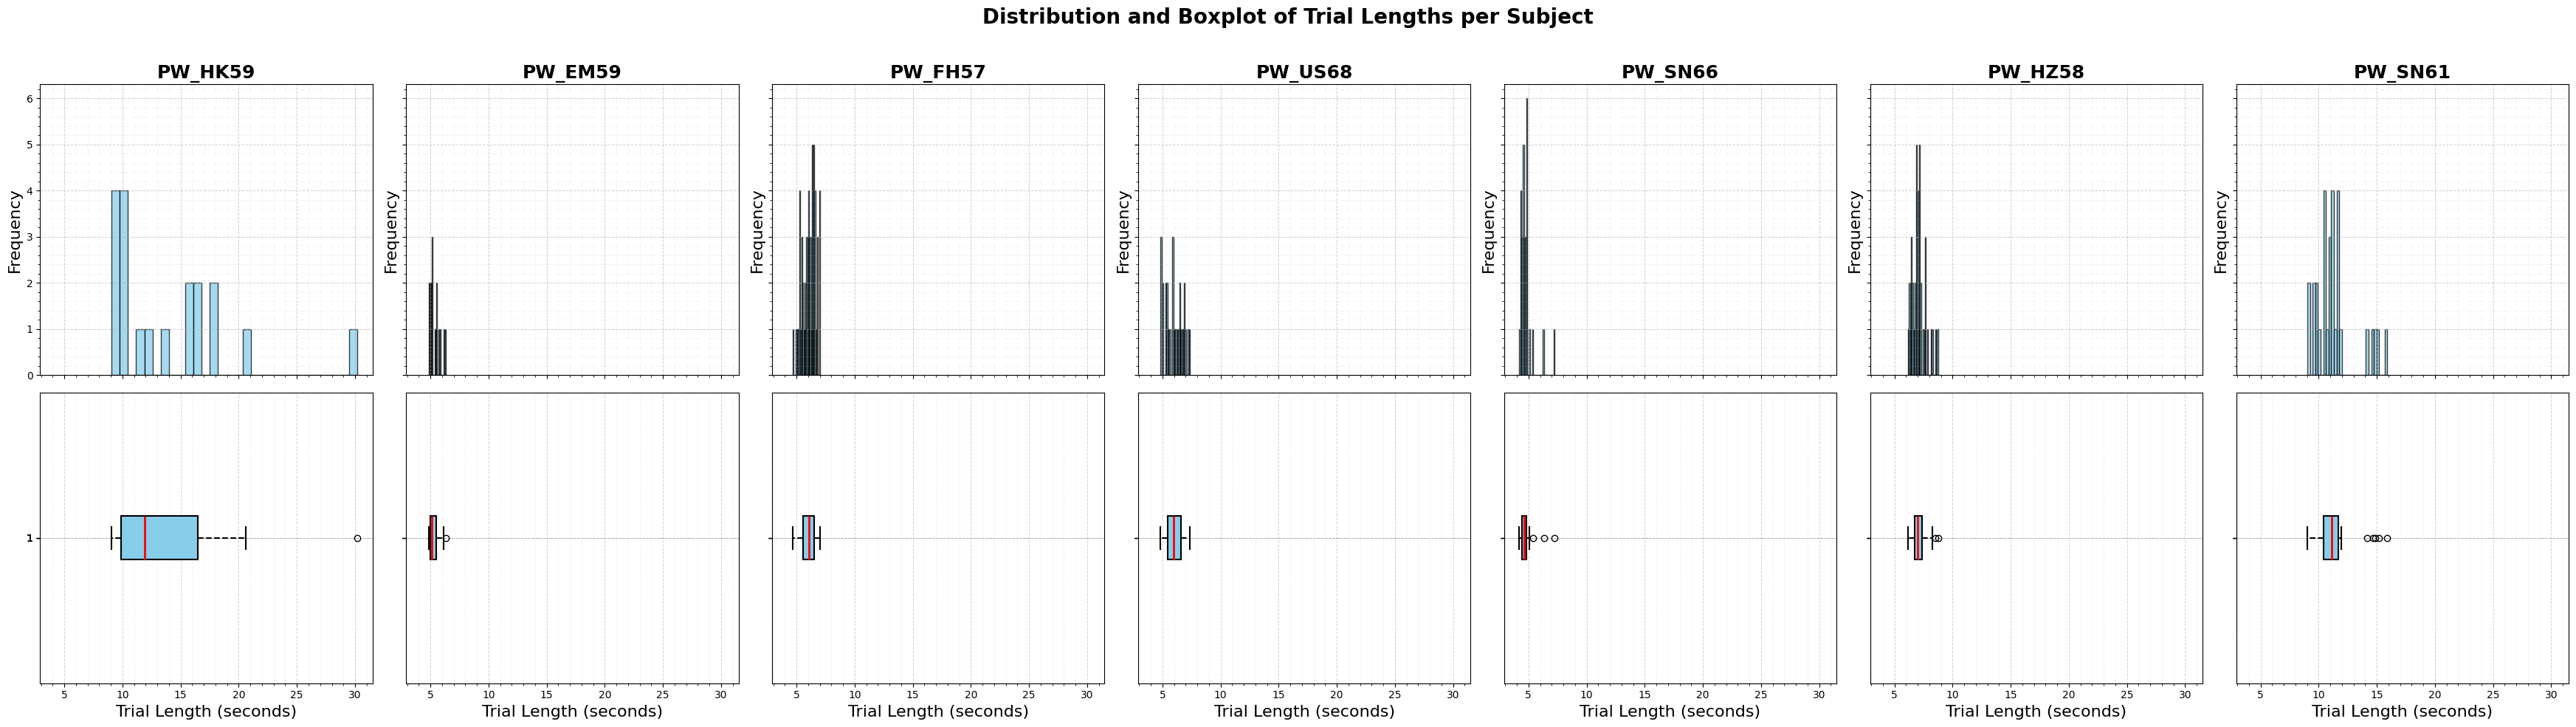

In [24]:
Visualise.plot_trial_lengths_per_subject_distr(subjects_lfp_data_dict, lfp_sfreq, fig_save_path, fig_name='trial_lengths_per_subject_distr')

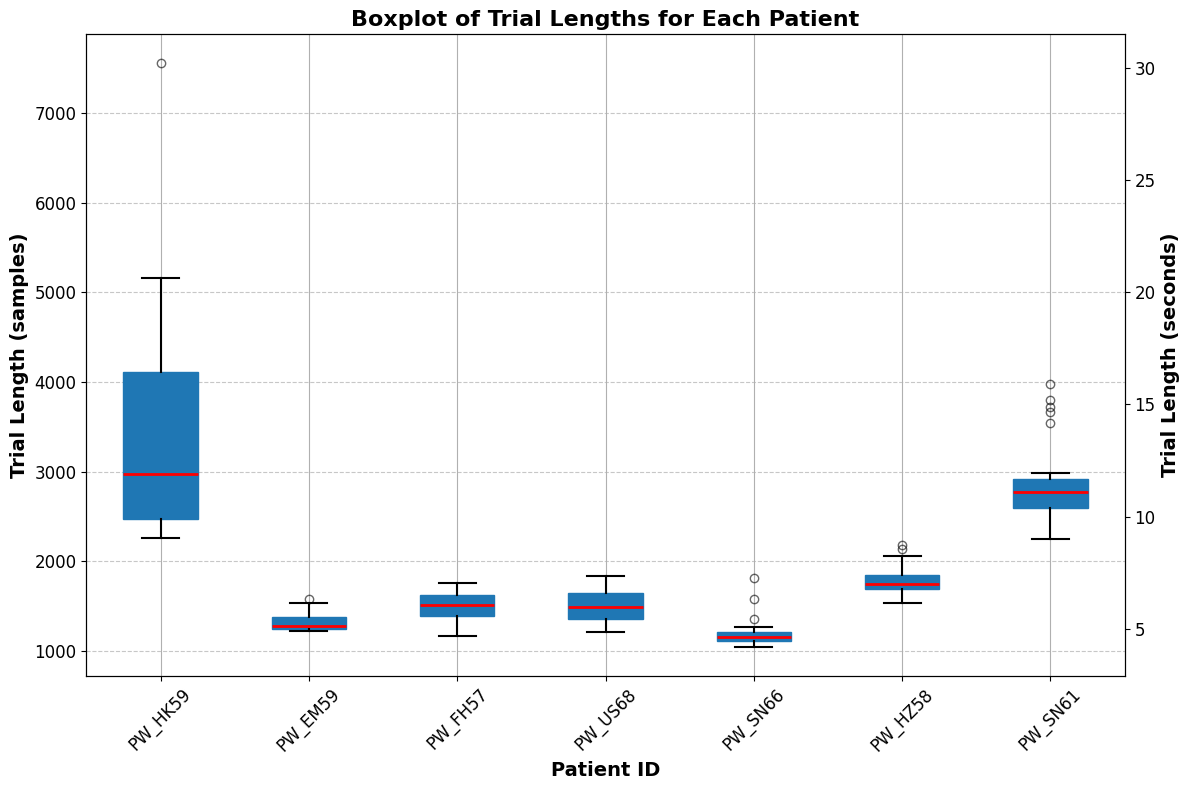

In [25]:
Visualise.plot_trial_lengths_per_subject_boxplot(subjects_lfp_data_dict, lfp_sfreq, fig_save_path, fig_name='trial_lengths_per_subject_boxplot')

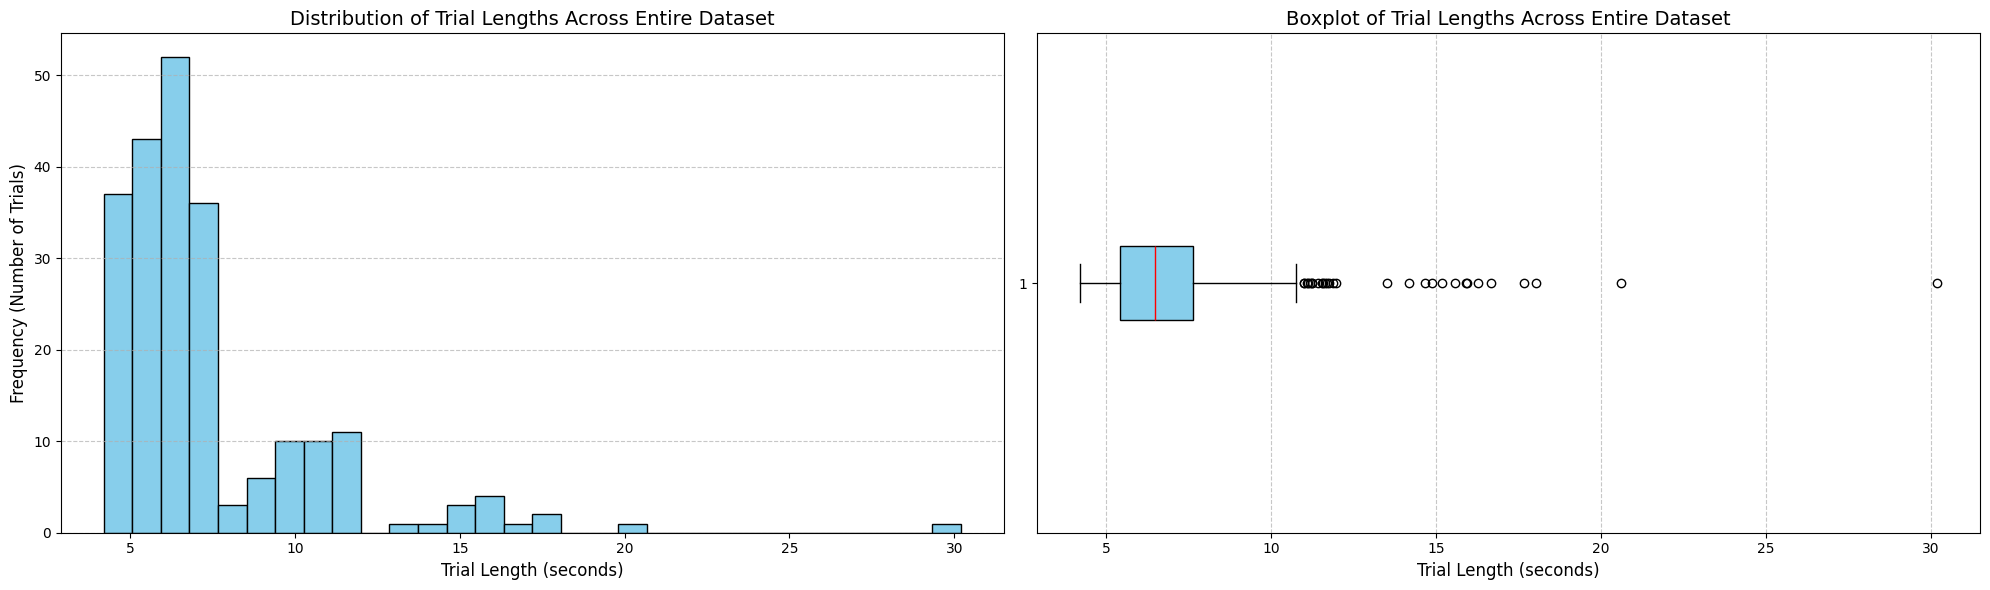

In [26]:
Visualise.plot_all_trial_lengths(subjects_lfp_data_dict, lfp_sfreq, fig_save_path, fig_name='all_trial_length_combined')

In [27]:
fig_save_path

'results/figures/processed_data'

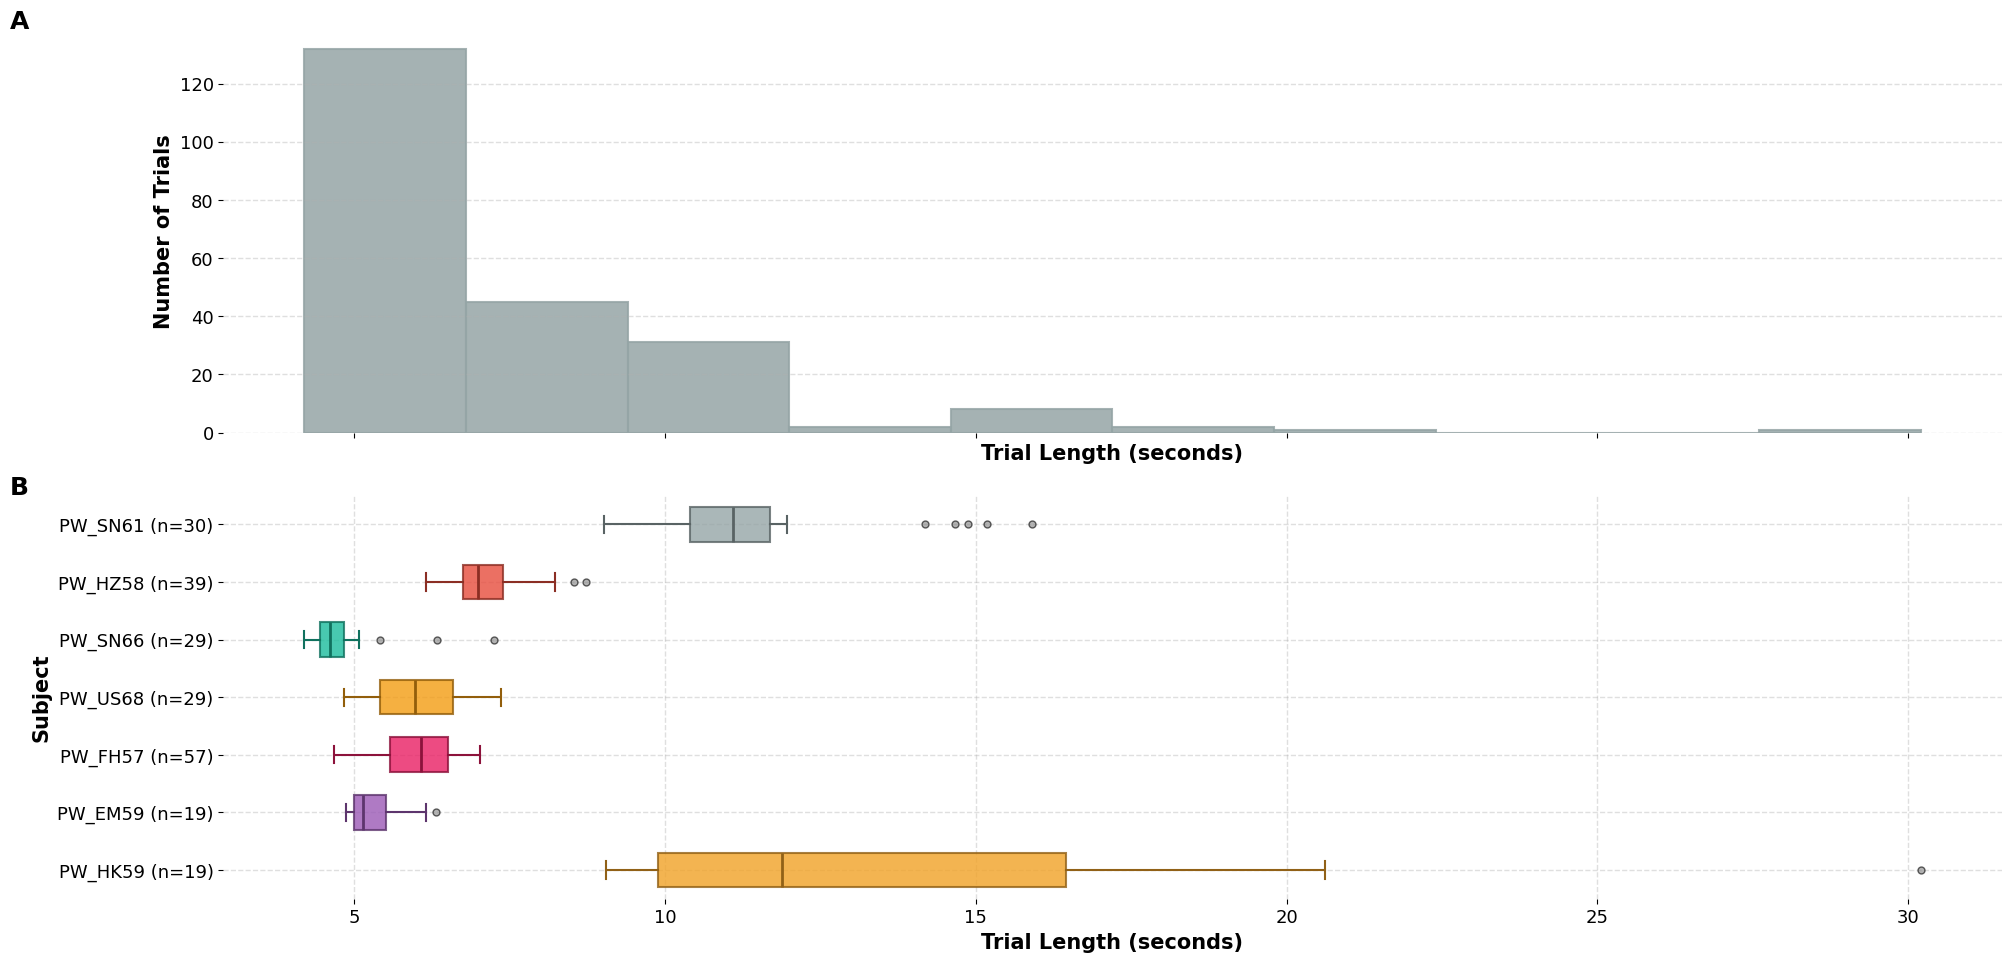

In [28]:
Visualise.plot_trial_length_histogram_and_boxplot(
    subjects_lfp_data_dict, lfp_sfreq=lfp_sfreq, save_path=fig_save_path, fig_name="trial_length_histogram_and_boxplot")    

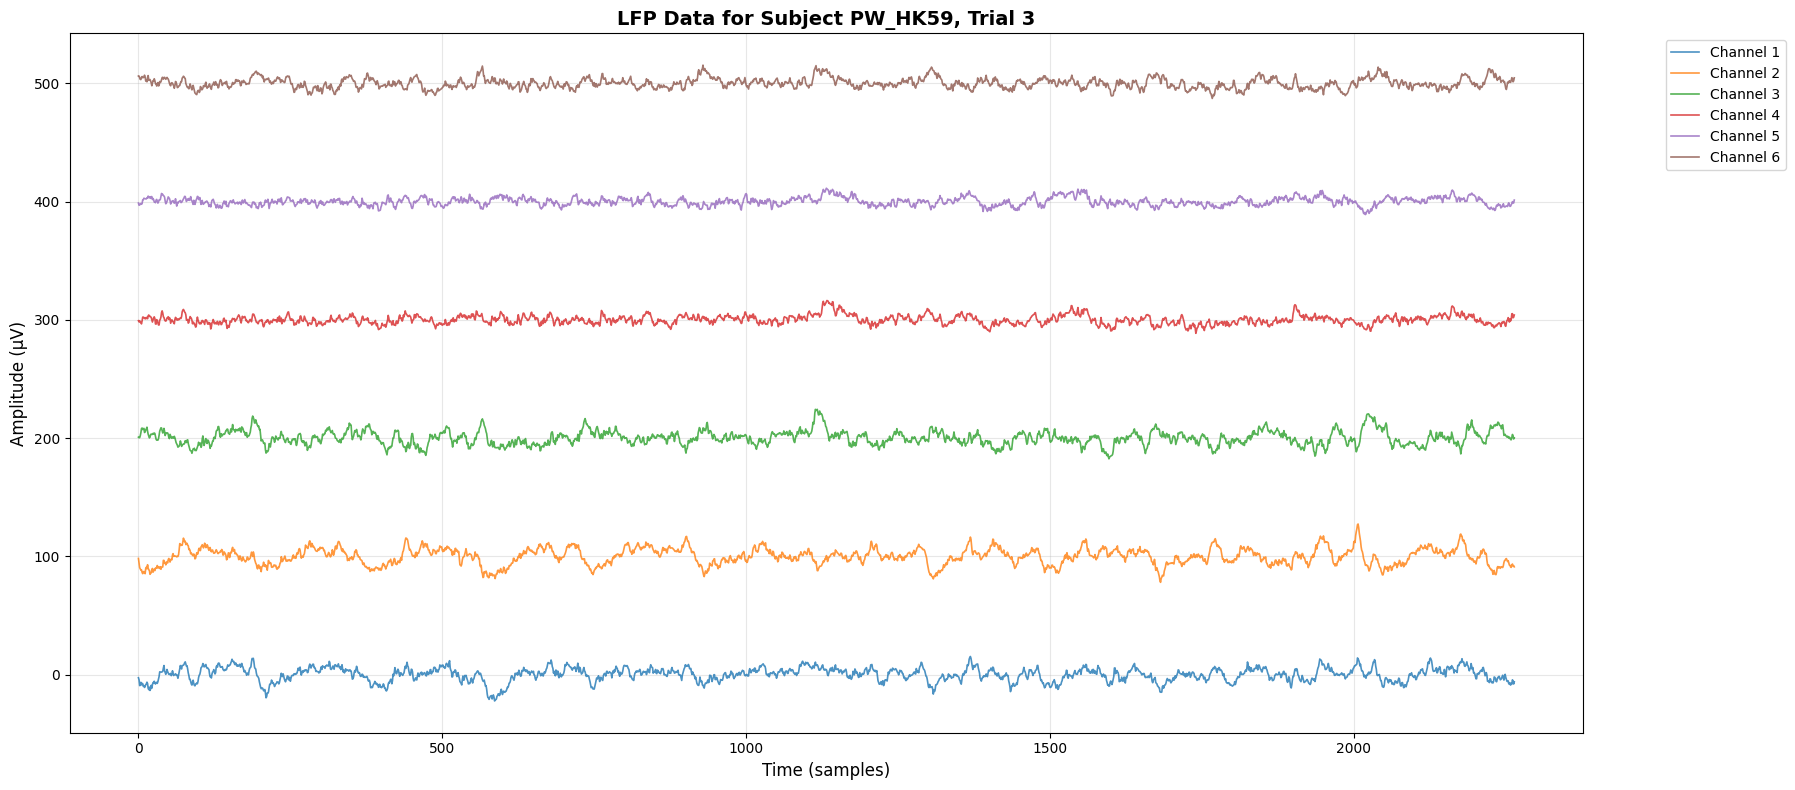

In [29]:
# subject = 'PW_HZ58'  # specify the subject
subject = 'PW_HK59'  # specify the subject
trial_index = 2  # specify the trial index

# Extract the data for the specified subject and trial
trial_data = subjects_lfp_data_dict[subject][trial_index]

# STANDARDIZED FIGURE SIZE AND LAYOUT
plt.figure(figsize=(18, 8))
for channel in range(trial_data.shape[0]):
    plt.plot(trial_data[channel, :] + channel * 100, 
             label=f'Channel {channel + 1}', linewidth=1.2, alpha=0.8)

plt.title(f'LFP Data for Subject {subject}, Trial {trial_index + 1}', 
          fontsize=14, fontweight='bold')
plt.xlabel('Time (samples)', fontsize=12)
plt.ylabel('Amplitude (µV)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




Computing PSD for PW_EM59, Trial 1...
Figure saved to: results/figures/processed_data/psd_PW_EM59_trial1


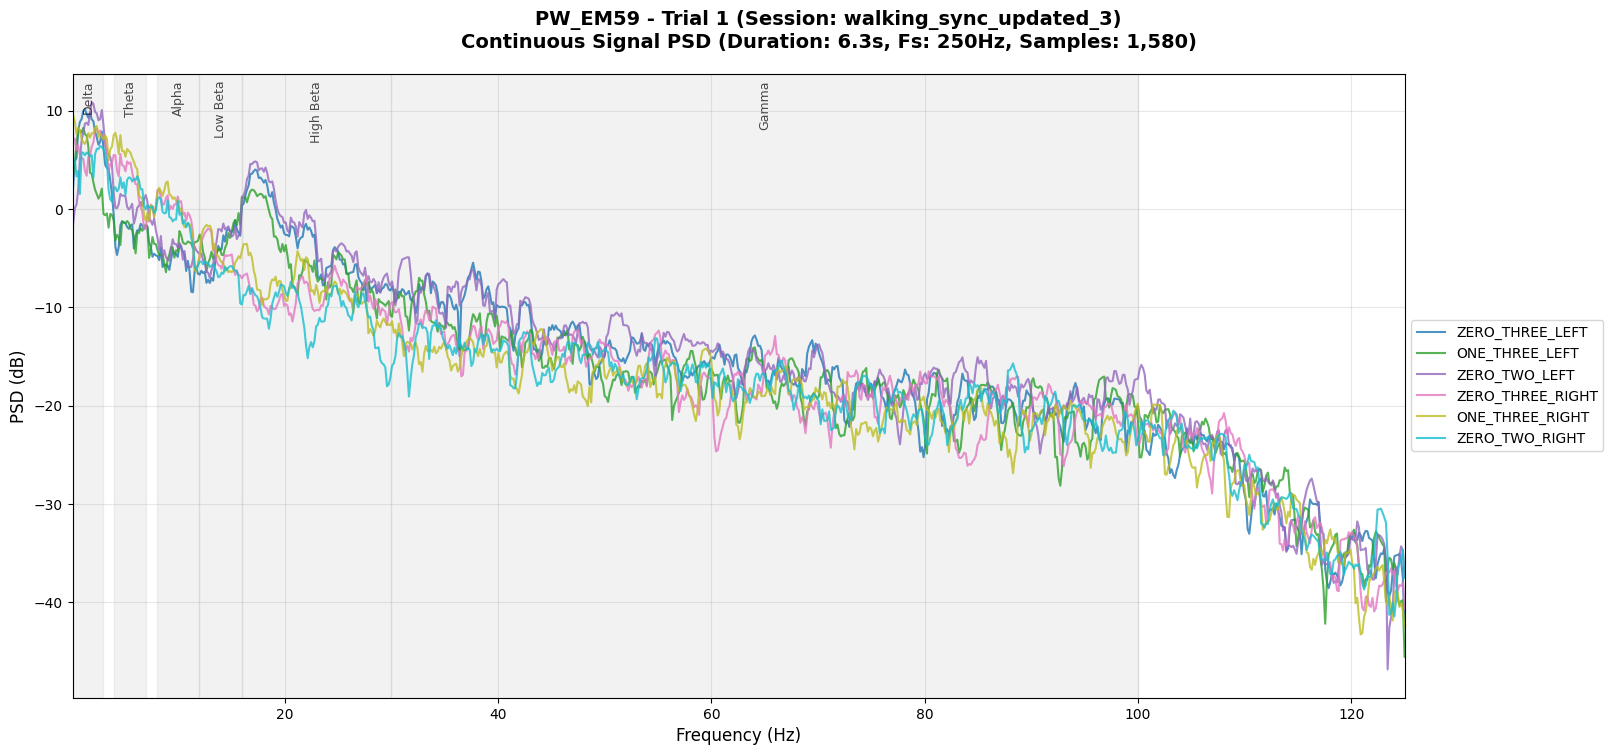

Computing spectrogram for PW_EM59, Trial 1, Channel 2...
Figure saved to: results/figures/processed_data/spectrogram_PW_EM59_trial1_ch2

Spectrogram Summary for PW_EM59, Trial 1, Channel ZERO_TWO_LEFT:
Session: walking_sync_updated_3
Duration: 6.3 seconds
Frequency range: 0.1 - 125.0 Hz
Time resolution: 0.500 seconds
Frequency resolution: 1.000 Hz


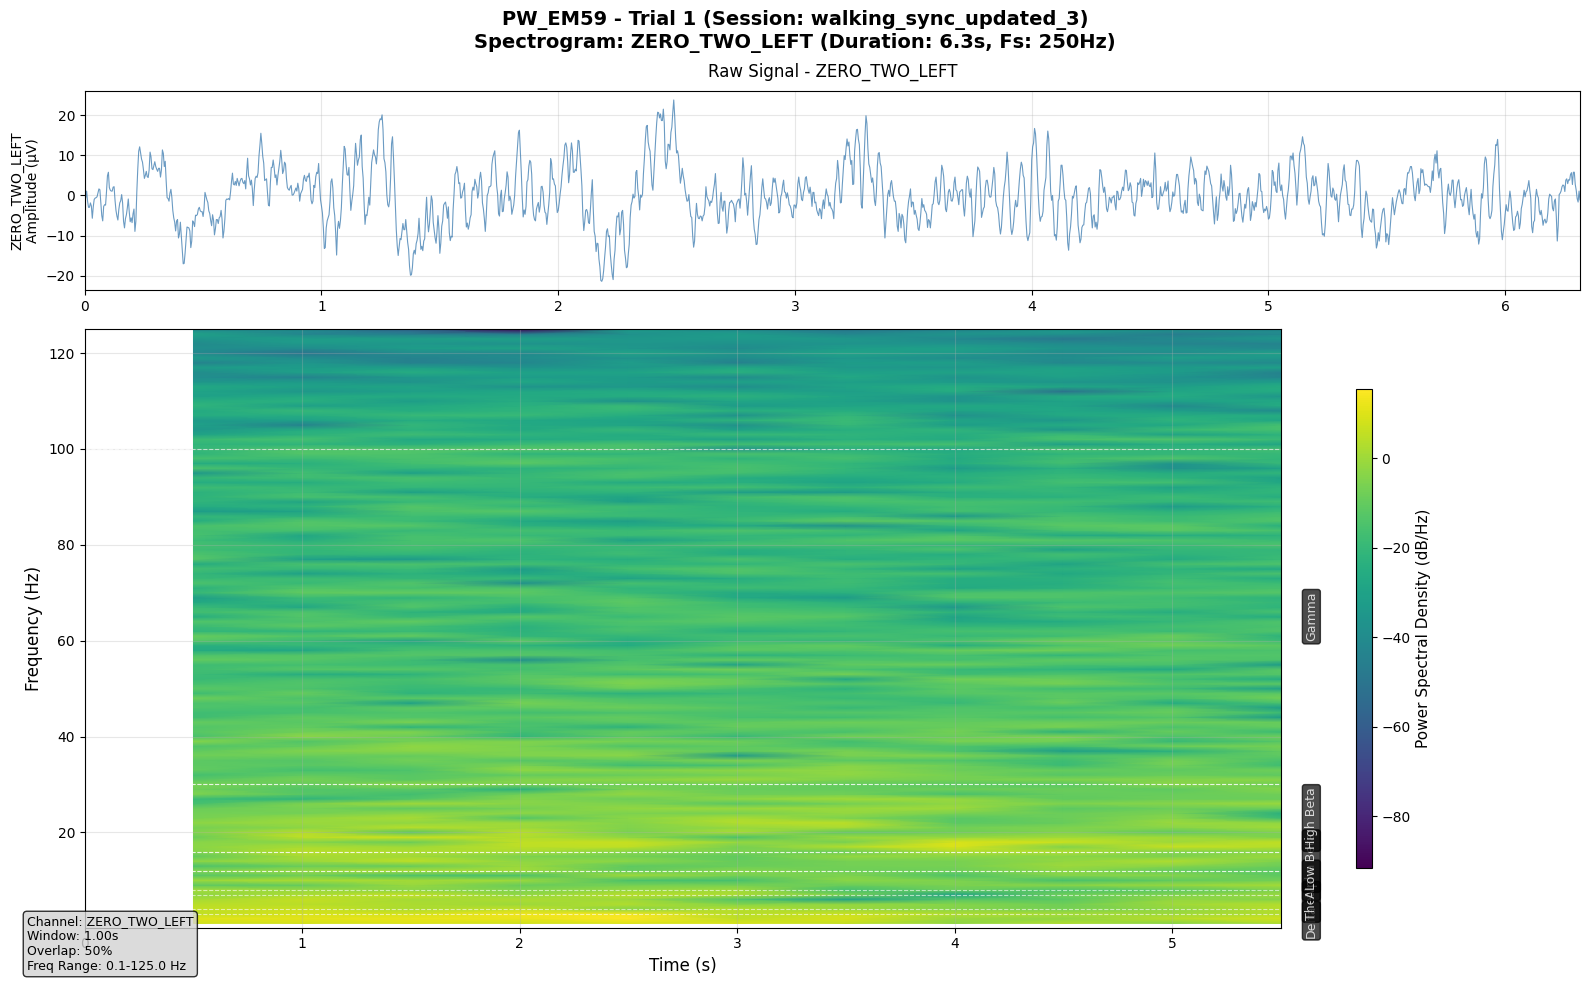

In [30]:
patient_name = 'PW_EM59'
trial_idx = 1
channel_idx = 2

Visualise.plot_single_patient_trial_psd(
    subjects_lfp_data_dict, 
    patient_name=patient_name, 
    trial_idx=trial_idx, 
    sfreq=lfp_sfreq, 
    fix_chs_names=fix_chs_names,
    subjects_session_trial_mapping=subjects_session_trial_mapping,
    save_path=fig_save_path, 
    fmin=0.1, 
    fmax=250/2,
    figsize=(18, 8),
    show_fig=True,
    fig_name=f'psd_{patient_name}_trial{trial_idx}')


Visualise.plot_single_patient_trial_spectrogram(
    subjects_lfp_data_dict, 
    patient_name=patient_name,
    trial_idx=trial_idx, 
    channel_idx=channel_idx,
    sfreq=lfp_sfreq, 
    fix_chs_names=fix_chs_names,
    subjects_session_trial_mapping=subjects_session_trial_mapping,
    save_path=fig_save_path,
    show_fig=True,
    fig_name=f'spectrogram_{patient_name}_trial{trial_idx}_ch{channel_idx}',
    fmin=0.1, 
    fmax=250/2)

In [31]:
# Visualise.plot_all_patients_trials_continuous(
#     subjects_lfp_data_dict=subjects_lfp_data_dict,
#     subjects_event_idx_dict=subjects_event_idx_dict,
#     sfreq=lfp_sfreq,
#     save_path=fig_save_path,
#     fig_name="lfp_continuous_all_patients_trials",
#     subjects_session_trial_mapping=subjects_session_trial_mapping,
#     channel_names=DataProcessor.rename_lfp_channels(fix_chs_names),
#     # max_display_trials=10,
#     mod_start_idx=2,
#     mod_end_idx=6,
# )


# Filtering

1. High pass filter

In [32]:
# apply a high pass filter to the trials
apply_highpass_filter = False

def apply_highpass_filter(data, sfreq, highpass_freq, filter_order=2):

    nyquist = 0.5 * sfreq
    normal_cutoff = highpass_freq / nyquist
    b, a = sp.signal.butter(filter_order, normal_cutoff, btype='high', analog=False)
    
    return sp.signal.lfilter(b, a, data, axis=1)


if apply_highpass_filter:
    highpass_freq = 1.0 # in Hz
    for subject, trials in subjects_lfp_data_dict.items():
        filtered_trials = []
        for trial in trials:
            filtered_trial = apply_highpass_filter(
                data=trial,
                sfreq=lfp_sfreq,
                highpass_freq=highpass_freq,
                filter_order=2,
            )
            filtered_trials.append(filtered_trial)
        subjects_lfp_data_dict[subject] = filtered_trials

Computing PSD for PW_SN66, Trial 0...


Figure saved to: results/figures/processed_data/psd_PW_SN66_trial0


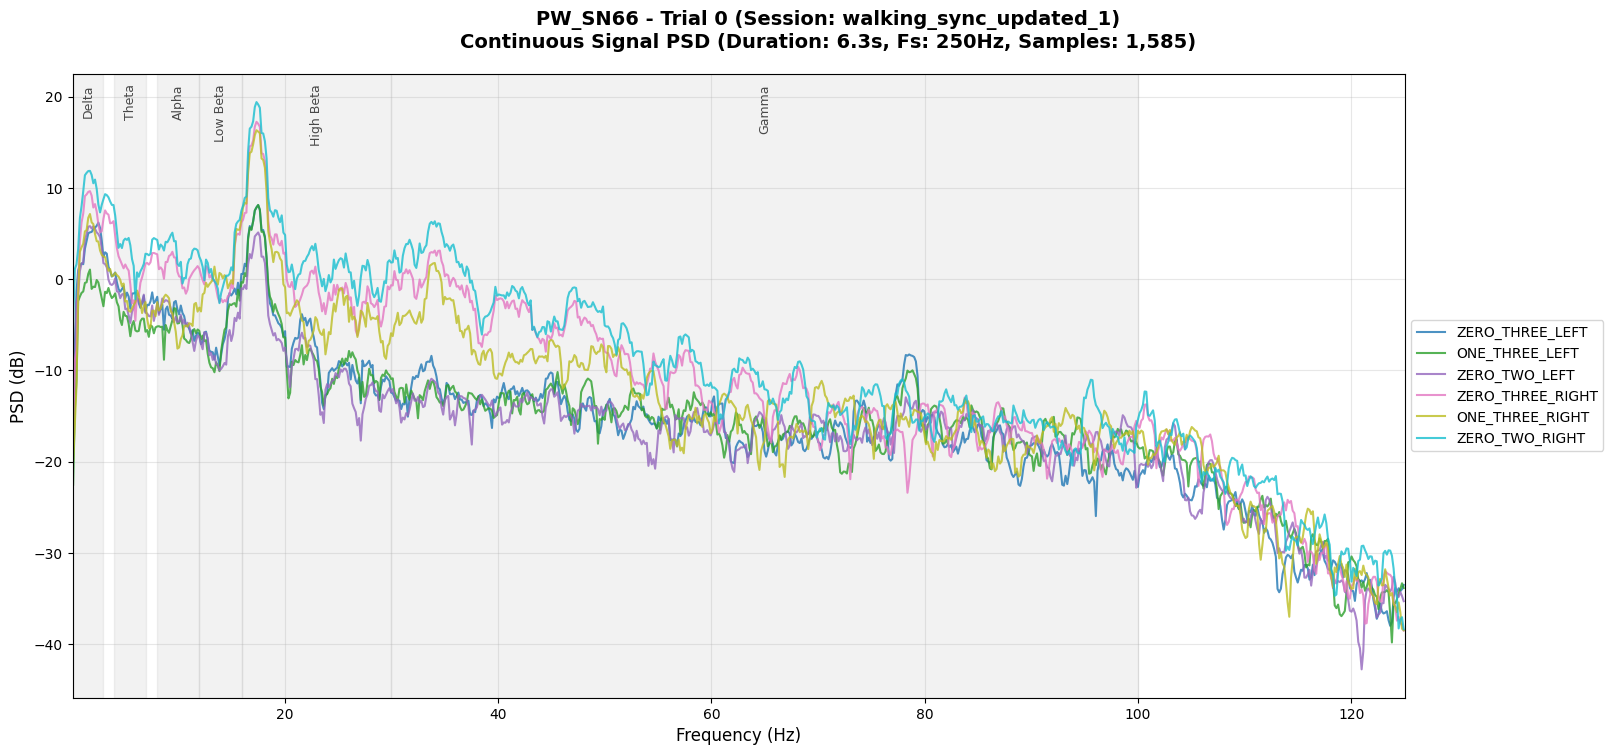

Computing spectrogram for PW_SN66, Trial 0, Channel 3...
Figure saved to: results/figures/processed_data/spectrogram_PW_SN66_trial0_ch3

Spectrogram Summary for PW_SN66, Trial 0, Channel ZERO_THREE_RIGHT:
Session: walking_sync_updated_1
Duration: 6.3 seconds
Frequency range: 0.1 - 125.0 Hz
Time resolution: 0.500 seconds
Frequency resolution: 1.000 Hz


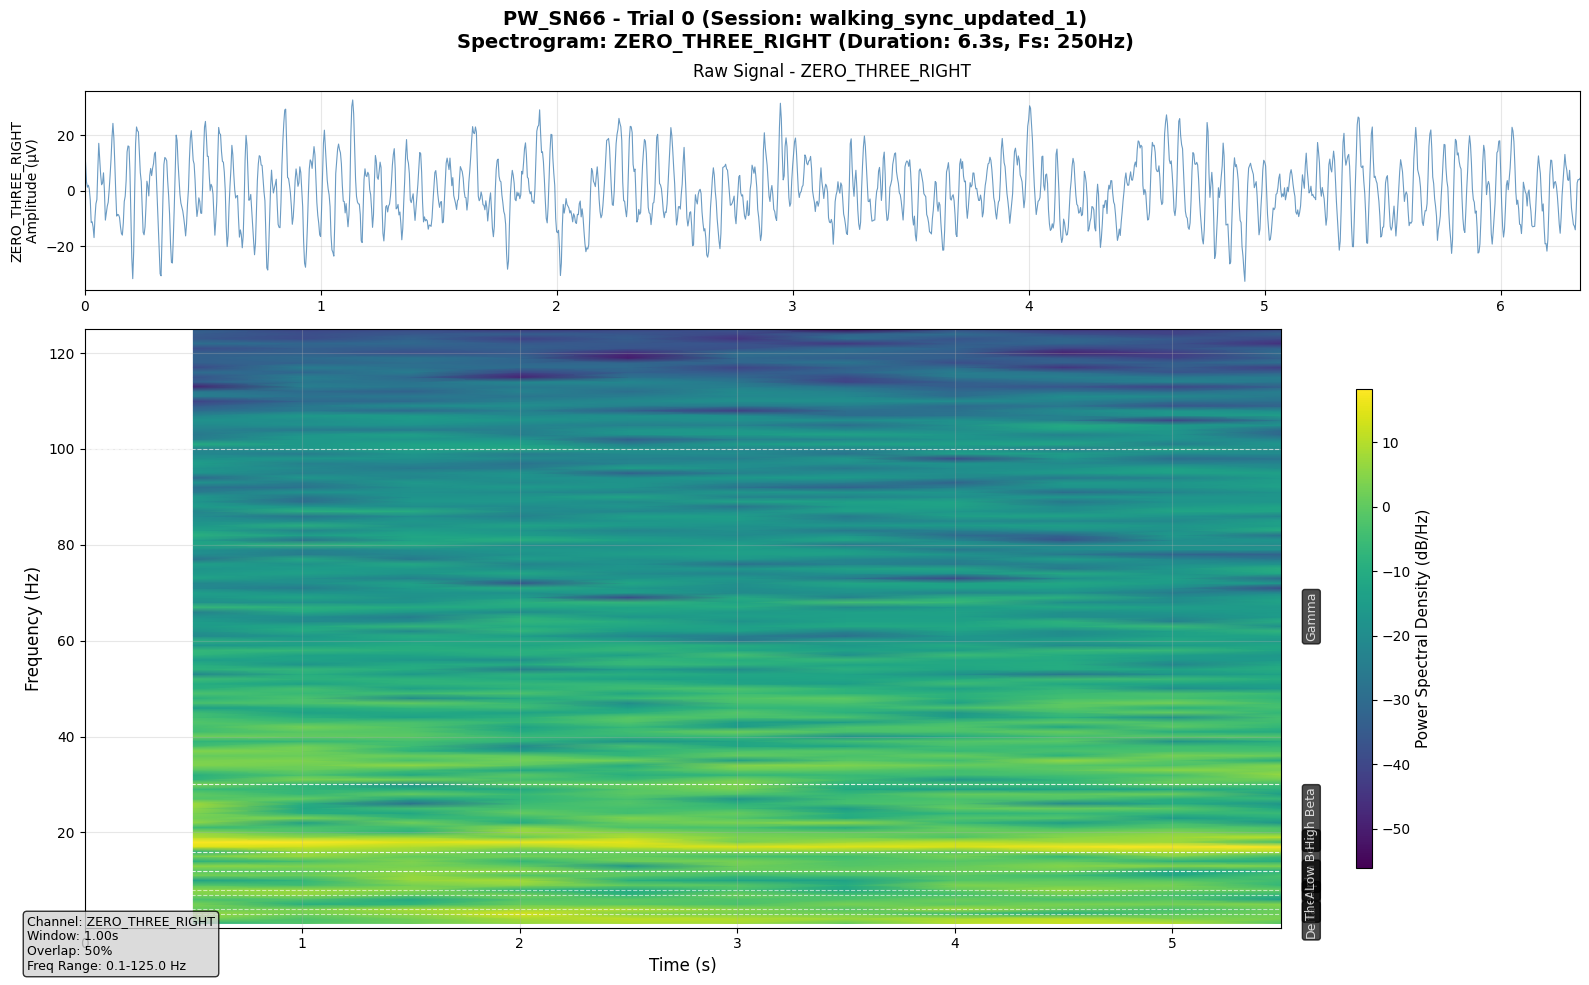

In [33]:
patient_name = 'PW_SN66'
trial_idx = 0
channel_idx = 3

Visualise.plot_single_patient_trial_psd(
    subjects_lfp_data_dict, 
    patient_name=patient_name, 
    trial_idx=trial_idx, 
    sfreq=lfp_sfreq, 
    fix_chs_names=fix_chs_names,
    subjects_session_trial_mapping=subjects_session_trial_mapping,
    save_path=fig_save_path, 
    fmin=0.1, 
    fmax=250/2,
    figsize=(18, 8),
    show_fig=True,
    fig_name=f'psd_{patient_name}_trial{trial_idx}')


Visualise.plot_single_patient_trial_spectrogram(
    subjects_lfp_data_dict, 
    patient_name=patient_name,
    trial_idx=trial_idx, 
    channel_idx=channel_idx,
    sfreq=lfp_sfreq, 
    fix_chs_names=fix_chs_names,
    subjects_session_trial_mapping=subjects_session_trial_mapping,
    save_path=fig_save_path,
    show_fig=True,
    fig_name=f'spectrogram_{patient_name}_trial{trial_idx}_ch{channel_idx}',
    fmin=0.1, 
    fmax=250/2)

---
# Segmentation

In [34]:
# subjects_lfp_data_dict, subjects_event_idx_dict, data
# subjects_lfp_data_dict['PW_EM59'][0].shape
# subjects_event_idx_dict['PW_FH57']

In [35]:
# create epochs
window_size=0.5
overlap=0.5
expand_transition=0.0
event_dict = {"normal_walking": 0, "modulation": 1}

mixed_window_policy = "keep_all"  # options: 'keep_all', 'drop_partial', 'drop_all_mixed'

patients = list(subjects_lfp_data_dict.keys())
patients_epochs = {}
for patient in patients:
    epochs = DataProcessor.segment_and_label_trials(
        trials=subjects_lfp_data_dict[patient],
        subjects_event_idx_dict=subjects_event_idx_dict[patient],
        ch_names=fix_chs_names,
        sfreq=lfp_sfreq,
        window_size=window_size,
        overlap=overlap,
        expand_transition=expand_transition,
        mixed_window_policy=mixed_window_policy,
        mod_start_idx= 2,
        mod_end_idx=6,
        event_dict=event_dict,
    )
    patients_epochs[patient] = epochs

Not setting metadata
1043 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
378 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1307 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
658 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
516 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1057 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1337 matching events found
No baseline correction applied
0 projection items activated


/home/orabem/gaitmod/gaitmod/utils/data_processor.py:706: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.EpochsArray(
/home/orabem/gaitmod/gaitmod/utils/data_processor.py:717: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  epochs.set_montage(montage)
/home/orabem/gaitmod/gaitmod/utils/data_processor.py:706: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.EpochsArray(
/home/orabem/gaitmod/gaitmod/utils/data_processor.py:717: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  epochs.set_montage(montage)
/home/orabem/gaitmod/gaitmod/utils/data_processor.py:706: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.EpochsArray(
/home/orabem/gaitmod/gaitmod/utils/data_processor.py:717: RuntimeWarning: Fiducial point na

In [36]:
# Count number of epochs per patient and per class label, and add total column
epoch_counts = []
for patient, epochs in patients_epochs.items():
    labels, counts = np.unique(epochs.events[:, -1], return_counts=True)
    label_map = {0: 'normal', 1: 'modulation'}
    row = {'patient_id': patient}
    total = 0
    for label, count in zip(labels, counts):
        row[label_map.get(label, str(label))] = count
        total += count
    row['total'] = total
    epoch_counts.append(row)

df_epoch_counts = pd.DataFrame(epoch_counts).fillna(0).astype({'normal': int, 'modulation': int, 'total': int})
df_epoch_counts

,patient_id,normal,modulation,total
0,PW_HK59,748,295,1043
1,PW_EM59,287,91,378
2,PW_FH57,827,480,1307
3,PW_US68,383,275,658
4,PW_SN66,391,125,516
5,PW_HZ58,648,409,1057
6,PW_SN61,866,471,1337


In [37]:
print("\n" + "="*60)
print("DATA STRUCTURE VALIDATION")
print("="*60)

# Validate consistency across data structures
for patient_name in patients_epochs.keys():
    epochs = patients_epochs[patient_name]
    n_trials_epochs = len(np.unique(epochs.events[:, 1]))
    
    n_trials_lfp = len(subjects_lfp_data_dict[patient_name]) if patient_name in subjects_lfp_data_dict else "N/A"
    n_trials_events = len(subjects_event_idx_dict[patient_name]) if patient_name in subjects_event_idx_dict else "N/A"
    
    print(f"{patient_name}:")
    print(f"  - Epochs trials: {n_trials_epochs}")
    print(f"  - LFP trials: {n_trials_lfp}")
    print(f"  - Event trials: {n_trials_events}")
    
    # Check if all are consistent
    if isinstance(n_trials_lfp, int) and isinstance(n_trials_events, int):
        if n_trials_epochs == n_trials_lfp == n_trials_events:
            print(f"  - Status: consistent")
        else:
            print(f"  - Status: INCONSISTENT")
    else:
        print(f"  - Status: PARTIAL DATA")
    print()

print("="*60)
print("FILTERING COMPLETE - ALL DATA STRUCTURES SYNCHRONIZED")
print("="*60)


DATA STRUCTURE VALIDATION
PW_HK59:
  - Epochs trials: 19
  - LFP trials: 19
  - Event trials: 19
  - Status: consistent

PW_EM59:
  - Epochs trials: 19
  - LFP trials: 19
  - Event trials: 19
  - Status: consistent

PW_FH57:
  - Epochs trials: 57
  - LFP trials: 57
  - Event trials: 57
  - Status: consistent

PW_US68:
  - Epochs trials: 29
  - LFP trials: 29
  - Event trials: 29
  - Status: consistent

PW_SN66:
  - Epochs trials: 29
  - LFP trials: 29
  - Event trials: 29
  - Status: consistent

PW_HZ58:
  - Epochs trials: 39
  - LFP trials: 39
  - Event trials: 39
  - Status: consistent

PW_SN61:
  - Epochs trials: 30
  - LFP trials: 30
  - Event trials: 30
  - Status: consistent

FILTERING COMPLETE - ALL DATA STRUCTURES SYNCHRONIZED


# Drop trials that do not meet required epoch counts per class

In [38]:
if False:
    # min_epochs can be an int (applies to all classes) or a dict (per class)
    min_epochs = 4  # e.g. {'normal_walking': 5, 'modulation': 5}

    trials_failing_epoch_criteria = DataProcessor.get_trials_with_insufficient_event_epochs(
        patients_epochs=patients_epochs,
        min_epochs=min_epochs,
        verbose=True,
    )

In [39]:
if False:
    patients_epochs, subjects_lfp_data_dict, subjects_event_idx_dict, subjects_session_trial_mapping = DataProcessor.drop_trials_from_epochs(
        patients_epochs=patients_epochs,
        trials_to_drop=trials_failing_epoch_criteria,
        subjects_lfp_data_dict=subjects_lfp_data_dict,
        subjects_event_idx_dict=subjects_event_idx_dict,
        subjects_session_trial_mapping=subjects_session_trial_mapping,
        verbose=True,
    )

# Drop out trials that do not contain epochs from both classes

Skip this one since the previous step imply this one

In [40]:
if False:
    # TRIAL FILTERING WITH DATA STRUCTURE SYNCHRONIZATION
    min_epochs_per_class = 1  # Minimum number of epochs required per class label

    # Use the filtering function to maintain data structure consistency
    # Update the original dictionaries with filtered results
    patients_epochs, subjects_lfp_data_dict, subjects_event_idx_dict = \
        DataProcessor.remove_trials_with_short_labels(
            patients_epochs=patients_epochs,
            subjects_lfp_data_dict=subjects_lfp_data_dict,
            subjects_event_idx_dict=subjects_event_idx_dict,
            min_epochs_per_class=min_epochs_per_class,
            verbose=True
        )

In [41]:
print("\n" + "="*60)
print("DATA STRUCTURE VALIDATION")
print("="*60)

# Validate consistency across data structures
for patient_name in patients_epochs.keys():
    epochs = patients_epochs[patient_name]
    n_trials_epochs = len(np.unique(epochs.events[:, 1]))
    
    n_trials_lfp = len(subjects_lfp_data_dict[patient_name]) if patient_name in subjects_lfp_data_dict else "N/A"
    n_trials_events = len(subjects_event_idx_dict[patient_name]) if patient_name in subjects_event_idx_dict else "N/A"
    
    print(f"{patient_name}:")
    print(f"  - Epochs trials: {n_trials_epochs}")
    print(f"  - LFP trials: {n_trials_lfp}")
    print(f"  - Event trials: {n_trials_events}")
    
    # Check if all are consistent
    if isinstance(n_trials_lfp, int) and isinstance(n_trials_events, int):
        if n_trials_epochs == n_trials_lfp == n_trials_events:
            print(f"  - Status: consistent")
        else:
            print(f"  - Status: INCONSISTENT")
    else:
        print(f"  - Status: ? PARTIAL DATA")
    print()

print("="*60)
print("FILTERING COMPLETE - ALL DATA STRUCTURES SYNCHRONIZED")
print("="*60)


DATA STRUCTURE VALIDATION
PW_HK59:
  - Epochs trials: 19
  - LFP trials: 19
  - Event trials: 19
  - Status: consistent

PW_EM59:
  - Epochs trials: 19
  - LFP trials: 19
  - Event trials: 19
  - Status: consistent

PW_FH57:
  - Epochs trials: 57
  - LFP trials: 57
  - Event trials: 57
  - Status: consistent

PW_US68:
  - Epochs trials: 29
  - LFP trials: 29
  - Event trials: 29
  - Status: consistent

PW_SN66:
  - Epochs trials: 29
  - LFP trials: 29
  - Event trials: 29
  - Status: consistent

PW_HZ58:
  - Epochs trials: 39
  - LFP trials: 39
  - Event trials: 39
  - Status: consistent

PW_SN61:
  - Epochs trials: 30
  - LFP trials: 30
  - Event trials: 30
  - Status: consistent

FILTERING COMPLETE - ALL DATA STRUCTURES SYNCHRONIZED


In [42]:
# Count number of epochs per patient and per class label, and add total column
epoch_counts = []
for patient, epochs in patients_epochs.items():
    labels, counts = np.unique(epochs.events[:, -1], return_counts=True)
    label_map = {0: 'normal', 1: 'modulation'}
    row = {'patient_id': patient}
    total = 0
    for label, count in zip(labels, counts):
        row[label_map.get(label, str(label))] = count
        total += count
    row['total'] = total
    epoch_counts.append(row)

df_epoch_counts = pd.DataFrame(epoch_counts).fillna(0).astype({'normal': int, 'modulation': int, 'total': int})
df_epoch_counts

,patient_id,normal,modulation,total
0,PW_HK59,748,295,1043
1,PW_EM59,287,91,378
2,PW_FH57,827,480,1307
3,PW_US68,383,275,658
4,PW_SN66,391,125,516
5,PW_HZ58,648,409,1057
6,PW_SN61,866,471,1337


In [43]:
def dummy_test_label_assignment():
    """Test segmentation and labeling for different window positions relative to modulation phase."""

    lfp_sfreq = 250  # Hz
    window_size_samples = int(0.5 * lfp_sfreq)  # 500ms window

    # Create a dummy LFP trial with arbitrary values (1 channel, 3000 samples)
    trial_data = np.zeros((1, 3000))  
    trials = [trial_data]

    # Define test cases
    test_cases = [
        # Windows shorter than modulation
        (200, 500, 0, "before modulation", 0),         # Case 1
        (200, 500, 100, "<50% start overlap", 0),      # Case 2
        (200, 500, 190, ">50% start overlap", 1),      # Case 3
        (200, 500, 250, "fully inside modulation", 1), # Case 4
        (200, 500, 400, ">50% end overlap", 1),        # Case 5
        (200, 500, 490, "<50% end overlap", 0),        # Case 6
        (200, 500, 600, "after modulation", 0),        # Case 7

        # Windows longer than modulation
        (200, 300, 0, "before modulation (long)", 0),       # Case 1
        (200, 300, 100, "<50% start overlap (long)", 0),    # Case 2
        (200, 300, 190, "fully containing modulation", 1),  # Case 3
        (200, 250, 190, "fully containing modulation", 0),  # Case 3
        (200, 300, 290, "<50% end overlap (long)", 0),      # Case 4
        (200, 300, 400, "after modulation (long)", 0)       # Case 5
    ]

    for mod_start, mod_end, window_start, description, expected_label in test_cases:
        window_end = window_start + window_size_samples

        # Calculate overlap ratio
        mod_overlap = max(0, min(window_end, mod_end) - max(window_start, mod_start))
        mod_ratio = mod_overlap / window_size_samples

        # Assign label based on >50% overlap
        predicted_label = 1 if mod_ratio > 0.5 else 0

        # Print debug info
        print(f"Test: {description} | Overlap: {mod_ratio:.2f} | Expected: {expected_label} | Predicted: {predicted_label}")

        # Assert correctness
        assert predicted_label == expected_label, f"Failed test: {description}"

# Run tests
dummy_test_label_assignment()

Test: before modulation | Overlap: 0.00 | Expected: 0 | Predicted: 0
Test: <50% start overlap | Overlap: 0.20 | Expected: 0 | Predicted: 0
Test: >50% start overlap | Overlap: 0.92 | Expected: 1 | Predicted: 1
Test: fully inside modulation | Overlap: 1.00 | Expected: 1 | Predicted: 1
Test: >50% end overlap | Overlap: 0.80 | Expected: 1 | Predicted: 1
Test: <50% end overlap | Overlap: 0.08 | Expected: 0 | Predicted: 0
Test: after modulation | Overlap: 0.00 | Expected: 0 | Predicted: 0
Test: before modulation (long) | Overlap: 0.00 | Expected: 0 | Predicted: 0
Test: <50% start overlap (long) | Overlap: 0.20 | Expected: 0 | Predicted: 0
Test: fully containing modulation | Overlap: 0.80 | Expected: 1 | Predicted: 1
Test: fully containing modulation | Overlap: 0.40 | Expected: 0 | Predicted: 0
Test: <50% end overlap (long) | Overlap: 0.08 | Expected: 0 | Predicted: 0
Test: after modulation (long) | Overlap: 0.00 | Expected: 0 | Predicted: 0


In [44]:
# epochs_with_events_path = os.path.join(fig_save_path, "epochs_with_events")
# os.makedirs(epochs_with_events_path, exist_ok=True)

# for patient in patients:
#     Visualise.plot_epochs_with_events(
#         patients_epochs,
#         patient,
#         window_size,
#         lfp_sfreq,
#         new_events_order,
#         subjects_event_idx_dict,
#         show_fig=False,
#         save_path=epochs_with_events_path,
#         fig_name=f'epochs_with_events_{patient}_{window_size}seconds')
    
#     print(f"Epochs with events for {patient}")


In [45]:
# print total number of epochs per class label
total_epochs_per_class = {}
for patient, epochs in patients_epochs.items():
    labels, counts = np.unique(epochs.events[:, -1], return_counts=True)
    for label, count in zip(labels, counts):
        if label not in total_epochs_per_class:
            total_epochs_per_class[label] = 0
        total_epochs_per_class[label] += count

print(f"Total epochs for both classes: {sum(total_epochs_per_class.values())}")
print(total_epochs_per_class)

# print ration of class labels
total_epochs = sum(total_epochs_per_class.values())
class_ratios = {label: count / total_epochs for label, count in total_epochs_per_class.items()}

print(class_ratios)

Total epochs for both classes: 6296
{0: 4150, 1: 2146}
{0: 0.659148665819568, 1: 0.340851334180432}


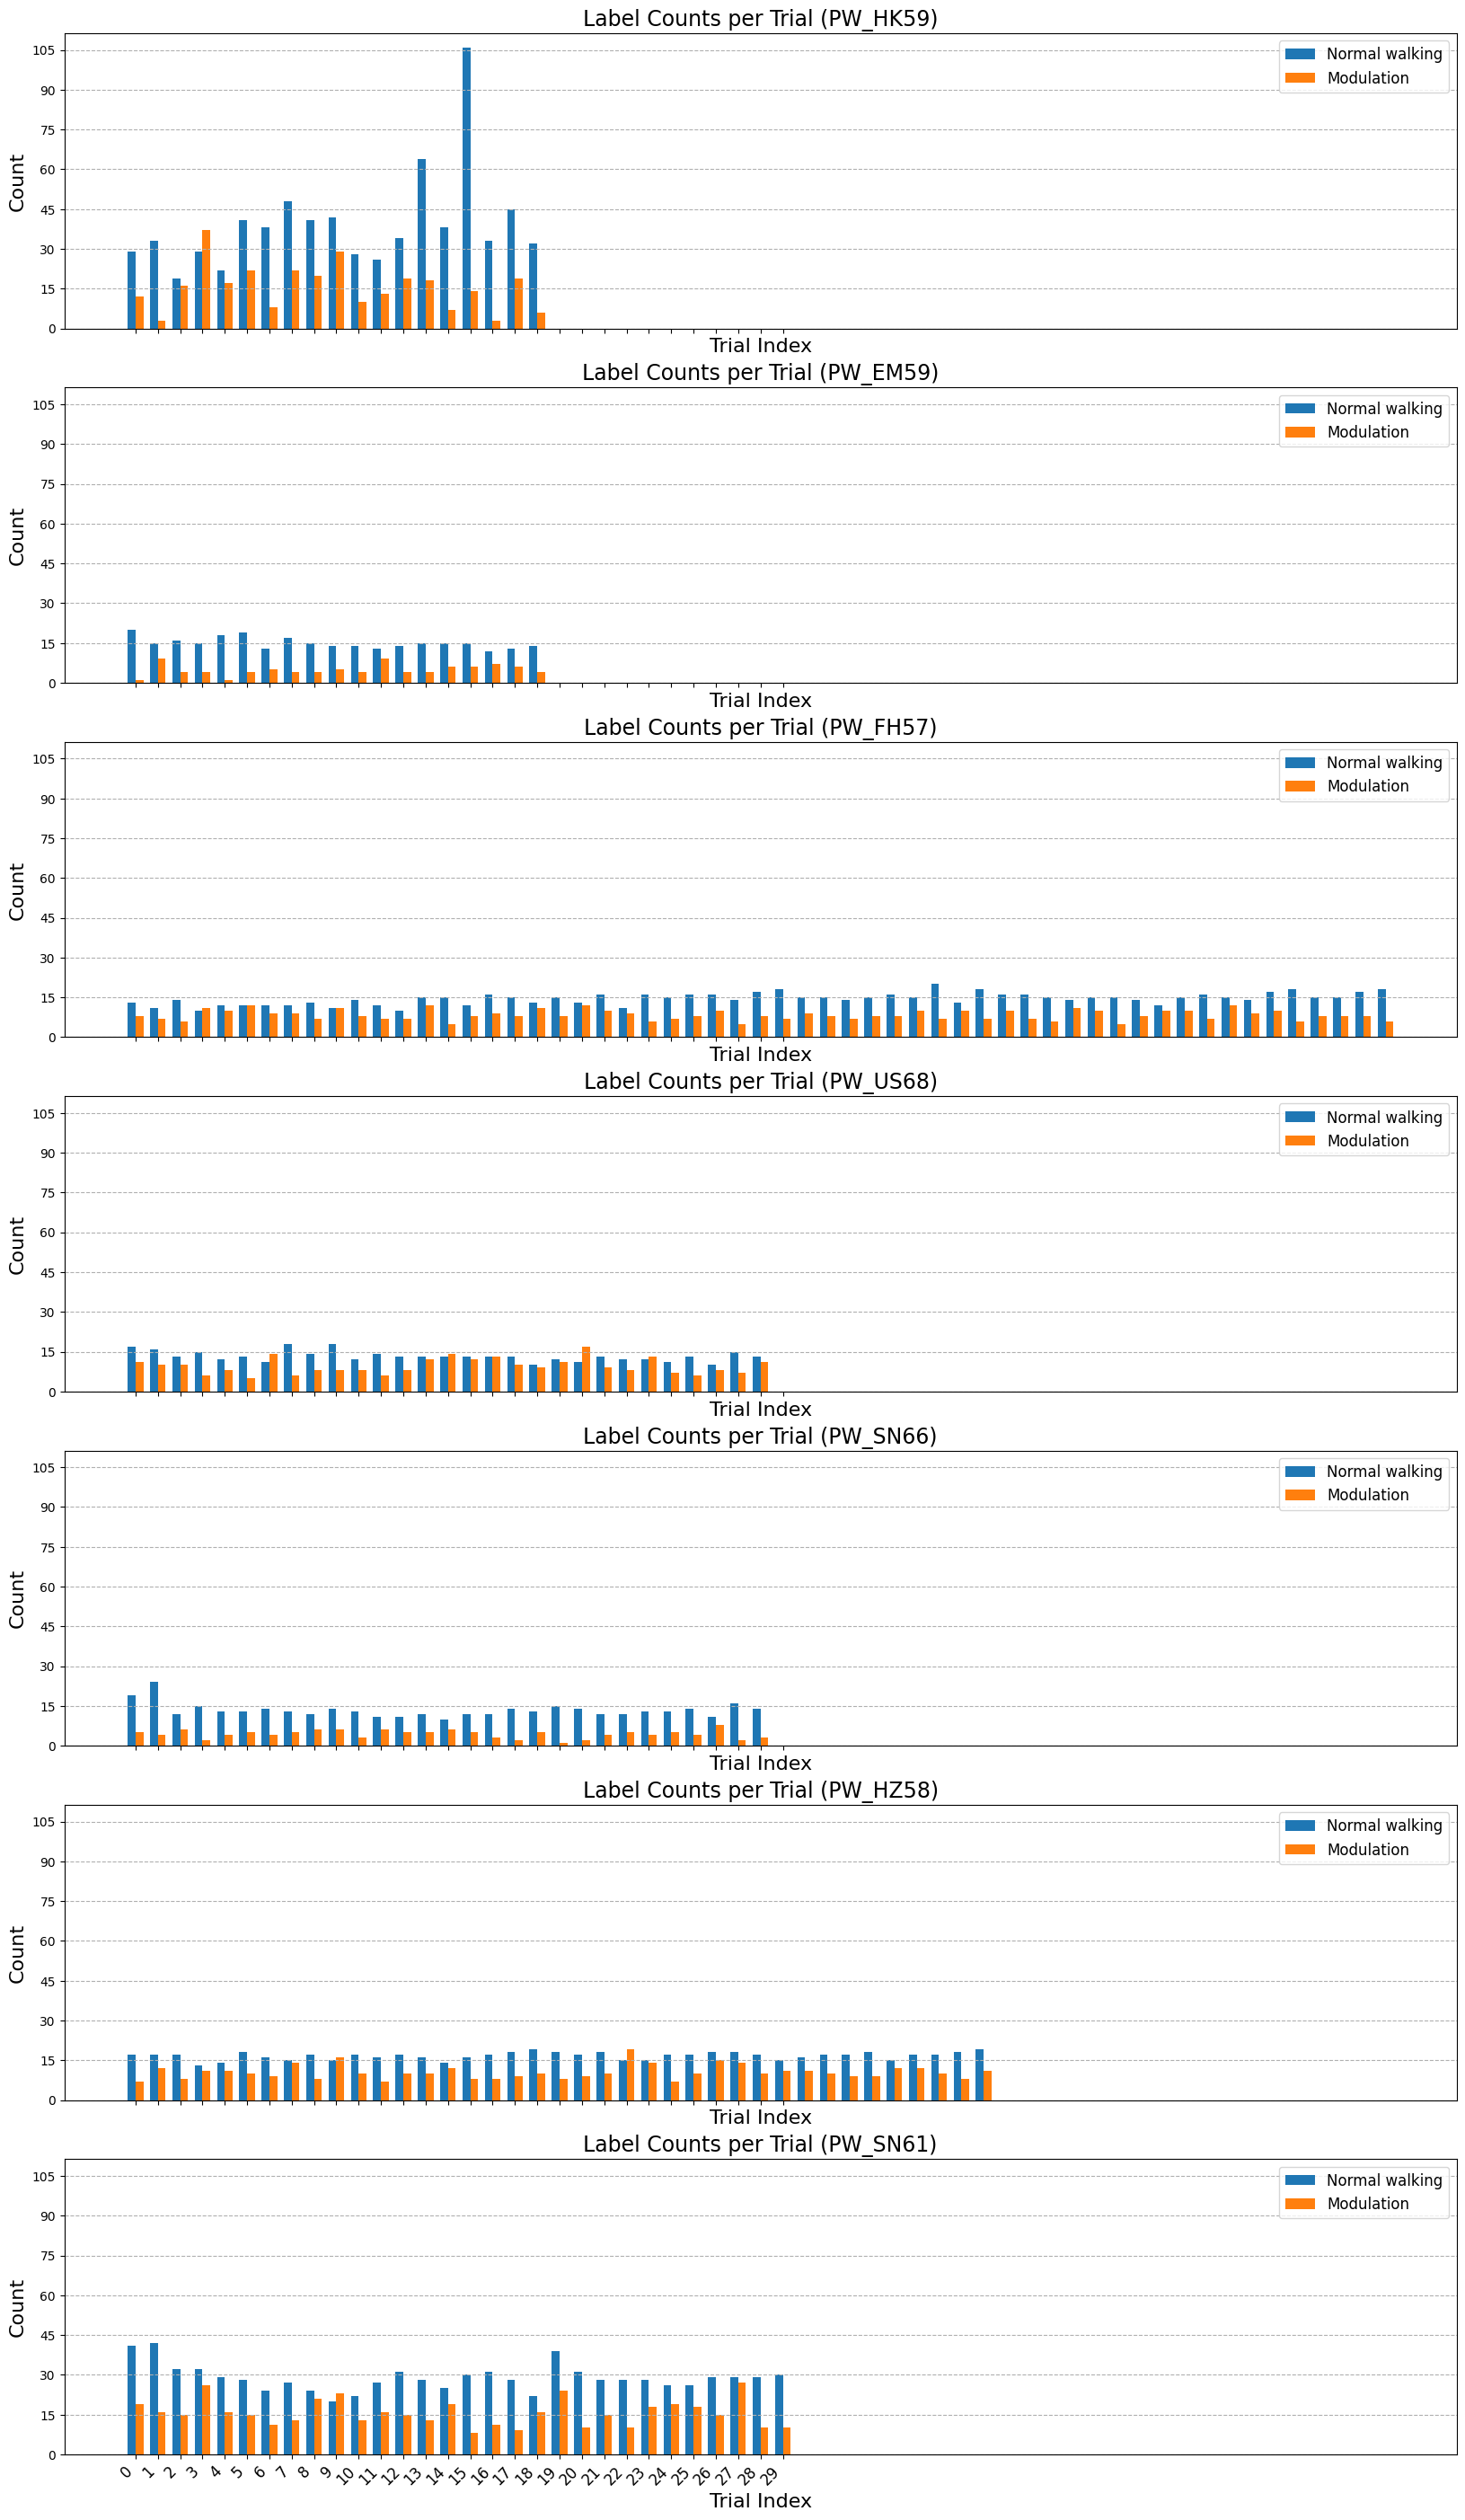

In [46]:
Visualise.plot_individual_trial_counts(patients_epochs, fig_save_path, 'individual_trial_counts')

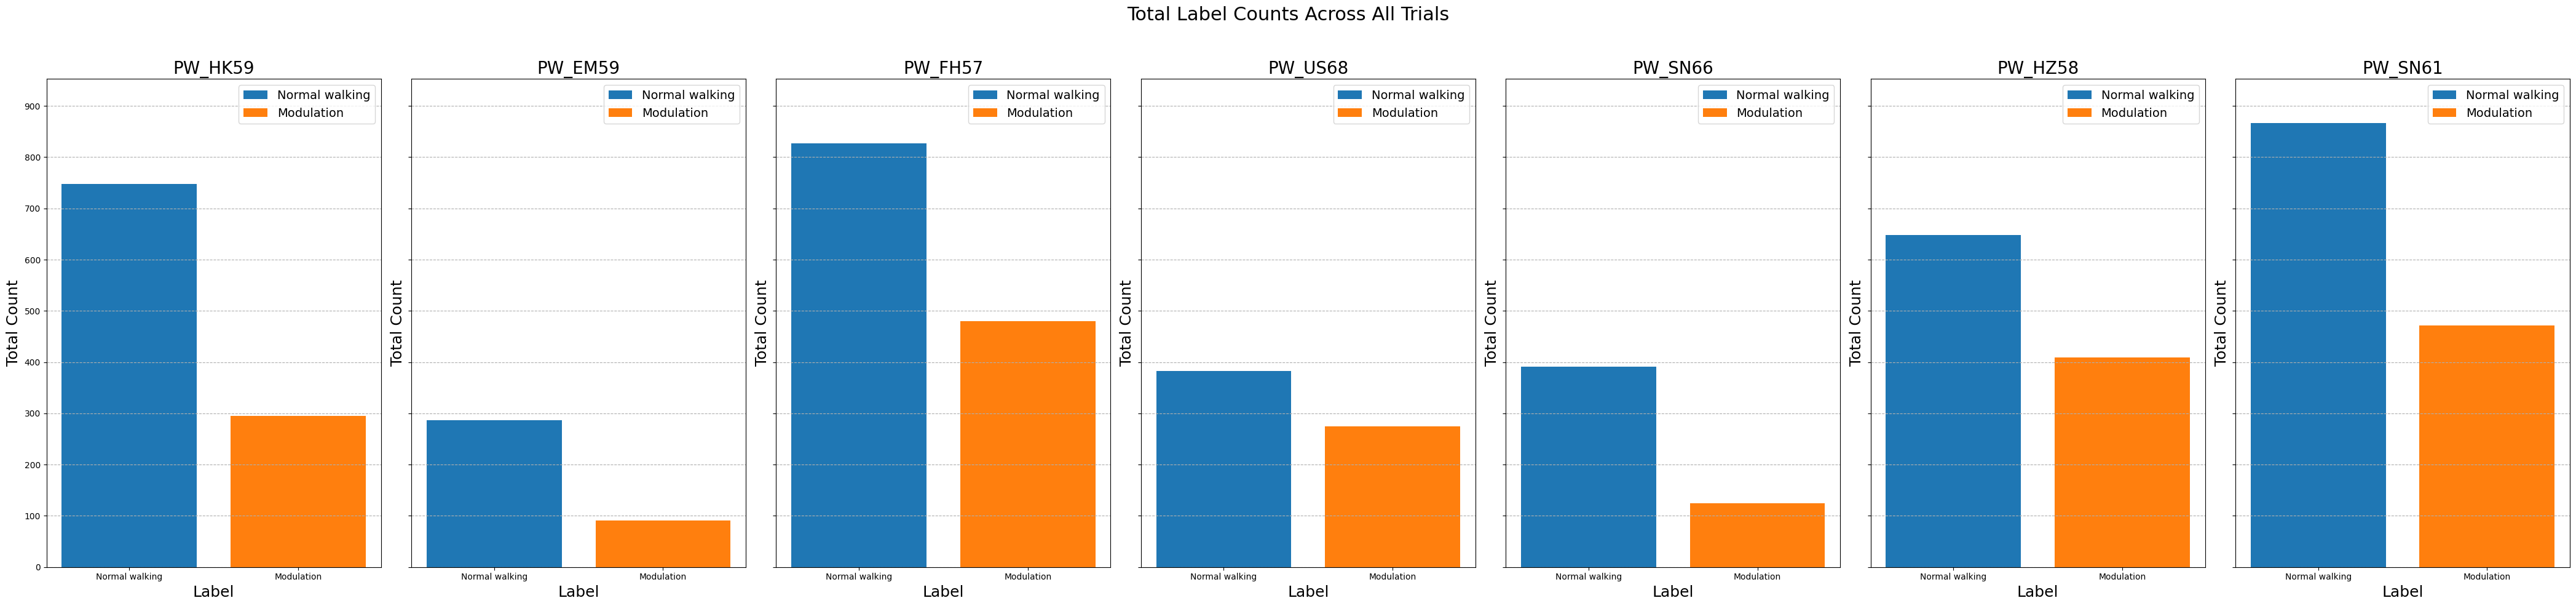

In [47]:
Visualise.plot_total_label_counts(patients_epochs, fig_save_path, 'total_label_counts')

In [48]:
# TODO: Plot epochs distribution per patient without distingushing events classes.

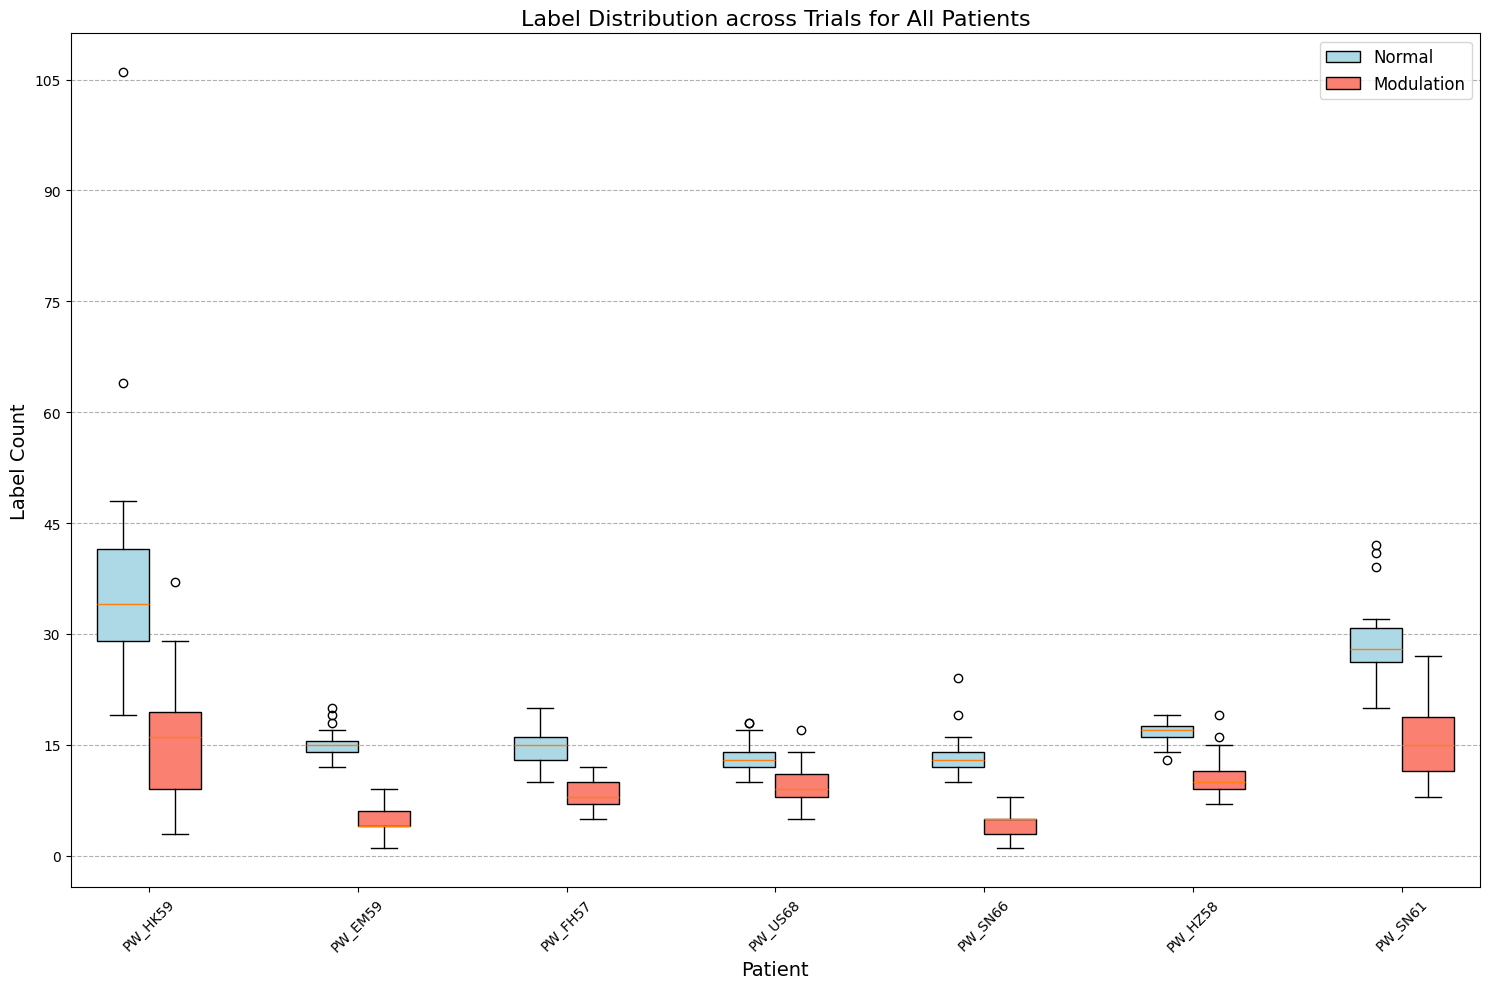

In [49]:
Visualise.plot_label_distribution_boxplot_all_patients(patients_epochs, fig_save_path, 'label_distribution_boxplot_all_patients')

/home/orabem/gaitmod/gaitmod/viz.py:470: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1.0])


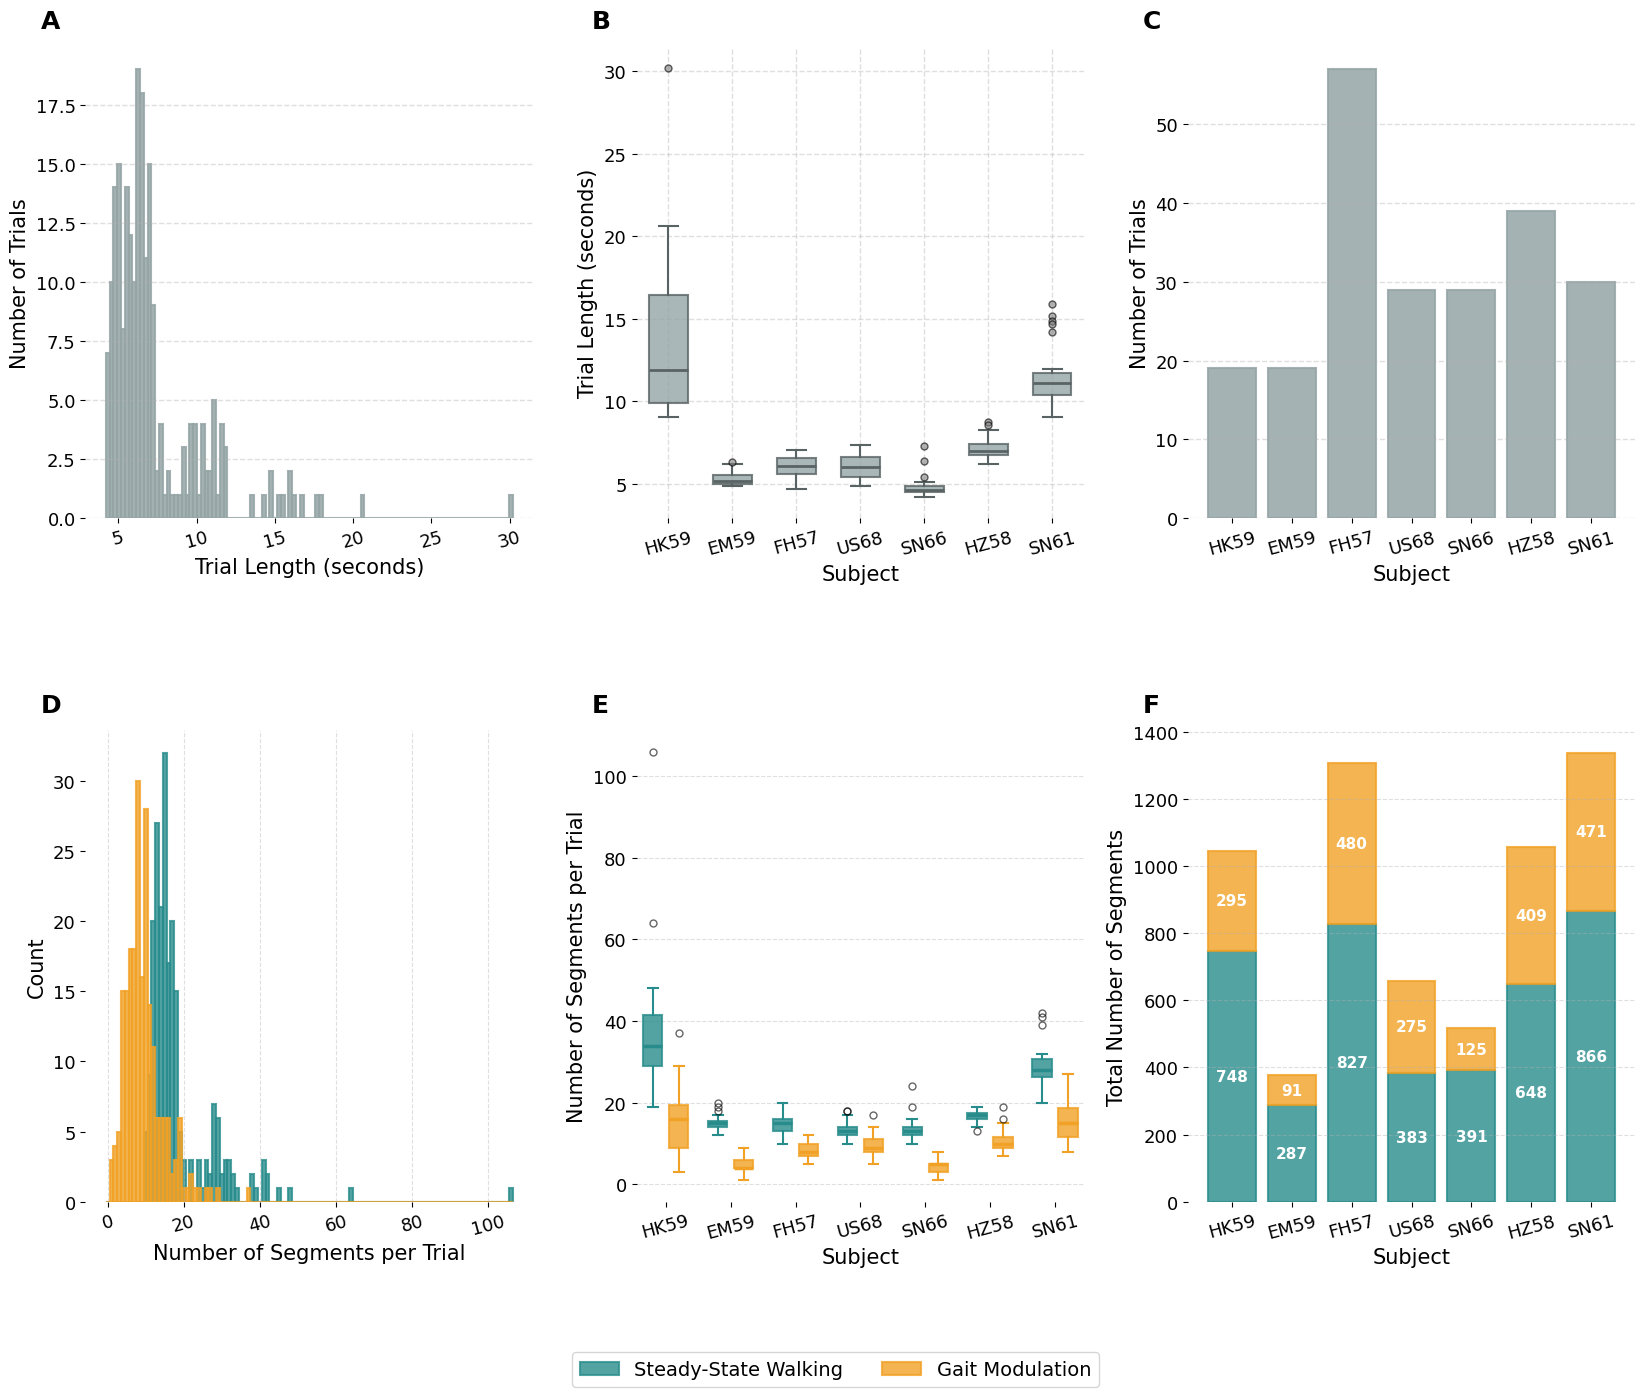

In [50]:
Visualise.plot_combined_trial_and_segments_distribution(subjects_lfp_data_dict, patients_epochs, lfp_sfreq, save_path=fig_save_path, fig_name="segment_trials_distr")

/home/orabem/gaitmod/gaitmod/viz.py:843: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1.0])


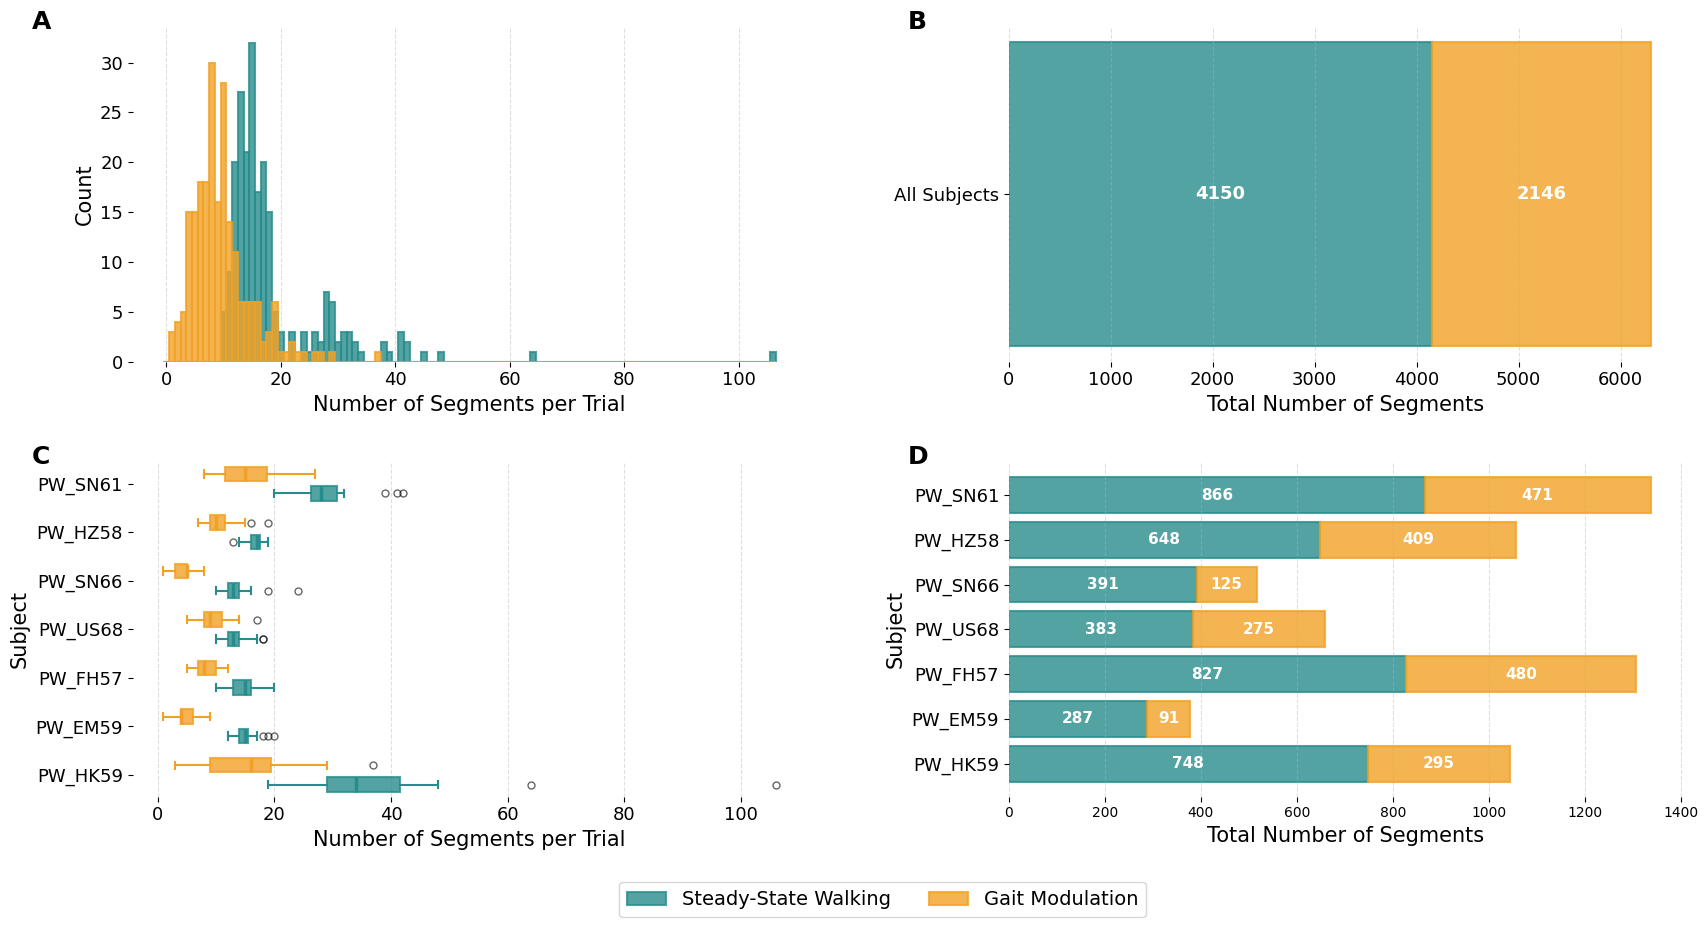

In [51]:
Visualise.plot_segments_distribution(patients_epochs, save_path=fig_save_path, fig_name='segments_distribution_all_patients')

In [52]:
# Find the trial(s) with the minimum number of segments (epochs) across all patients

min_segments = float('inf')
min_trials = []

for patient, epochs in patients_epochs.items():
    # Get unique trial indices from epochs.events[:, 1]
    trial_indices = np.unique(epochs.events[:, 1]).astype(int)
    for idx in trial_indices:
        n_segments = np.sum(epochs.events[:, 1] == idx)
        if n_segments < min_segments:
            min_segments = n_segments
            min_trials = [(patient, idx, n_segments)]
        elif n_segments == min_segments:
            min_trials.append((patient, idx, n_segments))

print(f"Minimum number of segments in a trial: {min_segments}")
for patient, idx, n_segments in min_trials:
    print(f"Subject: {patient}, Trial: {idx}, Segments: {n_segments}")
    # Print number of segments per class label for this trial
    epochs_this_patient = patients_epochs[patient]
    trial_mask = epochs_this_patient.events[:, 1] == idx
    labels, counts = np.unique(epochs_this_patient.events[trial_mask, -1], return_counts=True)
    print("  Segments per class label:")
    for label, count in zip(labels, counts):
        print(f"    Label {label}: {count}")

    # Print mod_start and mod_end event indices (samples and seconds)
    # Get the event markers for this trial from subjects_event_idx_dict
    event_markers = subjects_event_idx_dict[patient][idx]
    # According to your new_events_order, mod_start is index 2, mod_end is index 6
    mod_start_sample = event_markers[2]
    mod_end_sample = event_markers[6]
    print(f"  mod_start: {mod_start_sample} samples ({mod_start_sample / lfp_sfreq:.2f} s)")
    print(f"  mod_end:   {mod_end_sample} samples ({mod_end_sample / lfp_sfreq:.2f} s)")


Minimum number of segments in a trial: 15
Subject: PW_SN66, Trial: 16, Segments: 15
  Segments per class label:
    Label 0: 12
    Label 1: 3
  mod_start: 308 samples (1.23 s)
  mod_end:   465 samples (1.86 s)


# Filtering LFP Signals (not applied for now)

In [53]:
filter_segements = False

if filter_segements:
    # Practical demonstration: filter_order=None vs manual selection
    print("PRACTICAL DEMONSTRATION")
    print("=" * 50)

    # Simulate different epoch lengths to show adaptive behavior
    epoch_durations = [0.25, 0.5, 1.0, 2.0, 4.0]
    sfreq = 250.0

    print("Automatic filter order selection for different epoch lengths:")
    print("(This is what happens when you use filter_order=None)")
    print()

    for duration in epoch_durations:
        n_samples = int(duration * sfreq)
        
        # This is the same logic used in the adaptive filtering function
        if duration >= 2.0:
            auto_order = 4  # Standard order for long epochs
            recommendation = "OPTIMAL"
            reasoning = "Long epochs allow higher order filters"
        elif duration >= 1.0:
            auto_order = 3  # Reduced order for medium epochs
            recommendation = "GOOD"
            reasoning = "Medium epochs, balanced approach"
        else:
            auto_order = 2  # Minimal order for short epochs
            recommendation = "CONSTRAINED"
            reasoning = "Short epochs limit filter complexity"
        
        edge_artifacts = auto_order * 5  # Approximate edge artifact samples
        effective_samples = max(0, n_samples - 2 * edge_artifacts)
        effective_percentage = (effective_samples / n_samples) * 100 if n_samples > 0 else 0
        
        print(f"{duration}s epochs ({n_samples} samples):")
        print(f"   - Auto filter_order: {auto_order} ({recommendation})")
        print(f"   - Reasoning: {reasoning}")
        print(f"   - Edge artifacts: ~±{edge_artifacts} samples")
        print(f"   - Effective analysis: {effective_samples}/{n_samples} samples ({effective_percentage:.1f}%)")
        print()

    print("FOR THE CURRENT DATA (0.5s epochs):")
    print("-" * 40)
    print("- filter_order=None automatically selects filter_order=2")
    print("- This gives us ~±10 sample edge artifacts")
    print("- Effective analysis window: ~105/125 samples (84%)")
    print("- Good balance for short epochs")
    print()

    print("COMPARISON TABLE:")
    print("-" * 55)
    print("| Epoch | Auto | Manual | Edge Effects | Recommendation |")
    print("|-------|------|--------|---------------|----------------|")
    print("| 0.5s  | 2    | 1-3    | ±10 samples   | Use Auto=2     |")
    print("| 1.0s  | 3    | 2-4    | ±15 samples   | Use Auto=3     |") 
    print("| 2.0s  | 4    | 3-5    | ±20 samples   | Use Auto=4     |")
    print()

    print("KEY INSIGHT:")
    print("Using filter_order=None is like having an expert automatically")
    print("choose the best filter order for each dataset's characteristics.")
    print("It prevents common mistakes and optimizes performance!")

PRACTICAL DEMONSTRATION
Automatic filter order selection for different epoch lengths:
(This is what happens when you use filter_order=None)

0.25s epochs (62 samples):
   - Auto filter_order: 2 (CONSTRAINED)
   - Reasoning: Short epochs limit filter complexity
   - Edge artifacts: ~±10 samples
   - Effective analysis: 42/62 samples (67.7%)

0.5s epochs (125 samples):
   - Auto filter_order: 2 (CONSTRAINED)
   - Reasoning: Short epochs limit filter complexity
   - Edge artifacts: ~±10 samples
   - Effective analysis: 105/125 samples (84.0%)

1.0s epochs (250 samples):
   - Auto filter_order: 3 (GOOD)
   - Reasoning: Medium epochs, balanced approach
   - Edge artifacts: ~±15 samples
   - Effective analysis: 220/250 samples (88.0%)

2.0s epochs (500 samples):
   - Auto filter_order: 4 (OPTIMAL)
   - Reasoning: Long epochs allow higher order filters
   - Edge artifacts: ~±20 samples
   - Effective analysis: 460/500 samples (92.0%)

4.0s epochs (1000 samples):
   - Auto filter_order: 4 (OPT

In [54]:
if filter_segements:
    # Determine the optimal parameters based on epoch characteristics
    filter_params = DataProcessor.determine_adaptive_filter_params(
        patients_epochs,
        notch_freq=50.0,  # European power line frequency
        verbose=True
    )
    filter_params


DETERMINING ADAPTIVE FILTER PARAMETERS
EPOCH CHARACTERISTICS (consistent across all patients):
  - Duration: 0.50 s (125 samples)
  - Sampling rate: 250.0 Hz
  - Frequency resolution: 2.00 Hz
  - Nyquist frequency: 125.0 Hz

ANALYSIS WARNINGS:
  - Short epochs (0.50s) may cause edge artifacts

DETERMINED FILTER PARAMETERS:
  - Filter order: 2 (optimized for short epochs)
  - High-pass frequency: 2.0 Hz
  - Notch width: 4.0 Hz (optimized for moderate resolution)
  - Notch range: 48.0-52.0 Hz

    PARAMETER SELECTION REASONING:
    - Epoch duration (0.50s) -> filter_order=2
    - Frequency resolution (2.00 Hz) -> notch_width=4.0 Hz
    - Stability considerations -> highpass_freq=2.0 Hz
    


/home/orabem/gaitmod/gaitmod/utils/data_processor.py:1766: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = first_patient.get_data()


In [55]:
if filter_segements:
    
    # Apply filtering using the determined parameters

    # Zero-phase filtering: Preserves temporal relationships critical for gait analysis
    # High-pass filtering: Removes movement artifacts and slow drifts
    # NOTE: This can be applied offline for post-processing. Not suitable for real-time.
    
    # Notch filtering: Removes power line noise (50/60 Hz) -> no line noise observed in current data
    # Reflection padding: Prevents edge artifacts

    filtered_patients_epochs = DataProcessor.apply_adaptive_filtering_to_epochs(
        patients_epochs,
        apply_notch=False,                            # Remove 50 Hz power line noise
        apply_highpass=True,                          # Remove slow drifts
        apply_lowpass=False,       # Preserve broadband characteristics for HCTSA
        zero_phase=False,           # Preserve timing relationships
        notch_freq=False,                             # European power line frequency
        notch_width=False,     # Use determined parameter
        highpass_freq=filter_params['highpass_freq'], # Use determined parameter
        filter_order=filter_params['filter_order'],   # Use determined parameter
        padding_method='reflect',  # Minimize edge artifacts with reflection padding
        verbose=True
    )

Filtering 7 patients...
FILTERING CONFIGURATION:
  FREQUENCY DOMAIN FILTERS:
    - High-pass filter: >2.0 Hz (removes DC/drift/movement artifacts)
  TIME DOMAIN PROCESSING:
    - Phase filtering: Standard (sosfilt)
    - Filter order: 2
    - Edge padding: reflect

  PW_HK59: 1043 epochs 

/home/orabem/gaitmod/gaitmod/utils/data_processor.py:2072: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()  # Shape: (n_epochs, n_channels, n_samples)
/home/orabem/gaitmod/gaitmod/utils/data_processor.py:2137: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  filtered_epochs_obj = mne.EpochsArray(
/home/orabem/gaitmod/gaitmod/utils/data_processor.py:2072: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()  # Shape: (n_epochs, n_channels, n_samples)


  PW_EM59: 378 epochs 

/home/orabem/gaitmod/gaitmod/utils/data_processor.py:2137: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  filtered_epochs_obj = mne.EpochsArray(
/home/orabem/gaitmod/gaitmod/utils/data_processor.py:2072: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()  # Shape: (n_epochs, n_channels, n_samples)


  PW_FH57: 1307 epochs 

...

/home/orabem/gaitmod/gaitmod/utils/data_processor.py:2137: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  filtered_epochs_obj = mne.EpochsArray(
/home/orabem/gaitmod/gaitmod/utils/data_processor.py:2072: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()  # Shape: (n_epochs, n_channels, n_samples)


  PW_HZ58: 1057 epochs 

/home/orabem/gaitmod/gaitmod/utils/data_processor.py:2137: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  filtered_epochs_obj = mne.EpochsArray(
/home/orabem/gaitmod/gaitmod/utils/data_processor.py:2072: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()  # Shape: (n_epochs, n_channels, n_samples)


  PW_SN61: 1337 epochs Filtering complete: 6,296 epochs processed


/home/orabem/gaitmod/gaitmod/utils/data_processor.py:2137: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  filtered_epochs_obj = mne.EpochsArray(


In [56]:
if filter_segements:
    # Quick comparison of original vs filtered data
    print("FILTERING RESULTS SUMMARY")
    print("=" * 50)

    # Calculate overall statistics
    total_epochs_original = sum(len(epochs) for epochs in patients_epochs.values())
    total_epochs_filtered = sum(len(epochs) for epochs in filtered_patients_epochs.values())

    print(f"Total epochs processed: {total_epochs_original}")
    print(f"Total patients: {len(patients_epochs)}")
    print()

    print("Per-patient variance reduction:")
    print("-" * 30)
    for patient_name in patients_epochs.keys():
        orig_data = patients_epochs[patient_name].get_data()
        filt_data = filtered_patients_epochs[patient_name].get_data()
        
        orig_std = np.std(orig_data)
        filt_std = np.std(filt_data)
        variance_reduction = (1 - (filt_std**2 / orig_std**2)) * 100
        
        print(f"{patient_name}: {variance_reduction:.1f}% variance reduction")

FILTERING RESULTS SUMMARY
Total epochs processed: 6296
Total patients: 7

Per-patient variance reduction:
------------------------------
PW_HK59: 32.6% variance reduction
PW_EM59: 25.2% variance reduction
PW_FH57: 33.9% variance reduction
PW_US68: 41.1% variance reduction
PW_SN66: 15.8% variance reduction
PW_HZ58: 24.4% variance reduction
PW_SN61: 16.4% variance reduction


/tmp/ipykernel_1213857/848452926.py:17: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  orig_data = patients_epochs[patient_name].get_data()
/tmp/ipykernel_1213857/848452926.py:18: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  filt_data = filtered_patients_epochs[patient_name].get_data()
/tmp/ipykernel_1213857/848452926.py:17: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  orig_data = patients_epochs[patient_name].get_data()
/tmp/ipykernel_1213857/848452926.py:18: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  filt_data = filtered_patients_epochs[patient_name].get_data()
/tmp/ipykernel_1213857/848452926.py:17: FutureWarning:

/home/orabem/gaitmod/gaitmod/viz.py:2141: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  signal_orig = signal_orig.get_data()[epoch_idx, channel_idx, :]
/home/orabem/gaitmod/gaitmod/viz.py:2142: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  signal_filt = signal_filt.get_data()[epoch_idx, channel_idx, :]


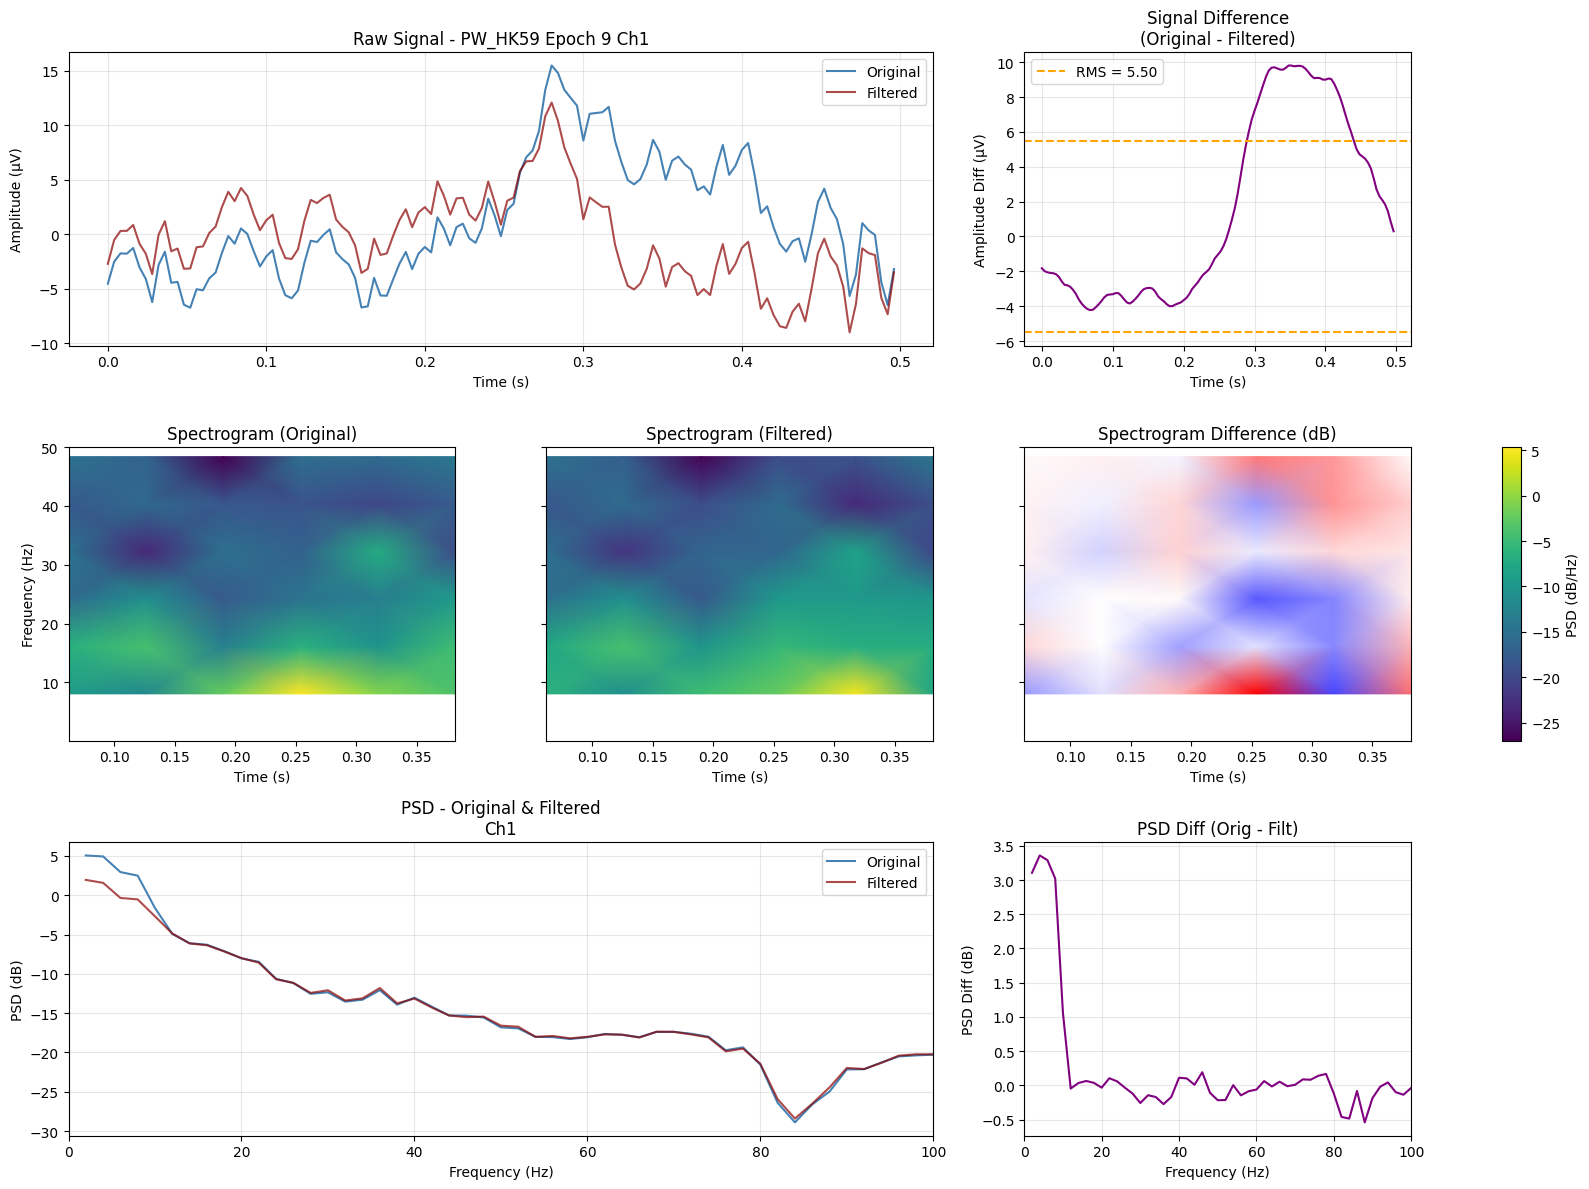

/home/orabem/gaitmod/gaitmod/viz.py:2270: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epoch_data_orig = epochs_orig.get_data()[epoch_idx]
/home/orabem/gaitmod/gaitmod/viz.py:2271: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epoch_data_filt = epochs_filt.get_data()[epoch_idx]


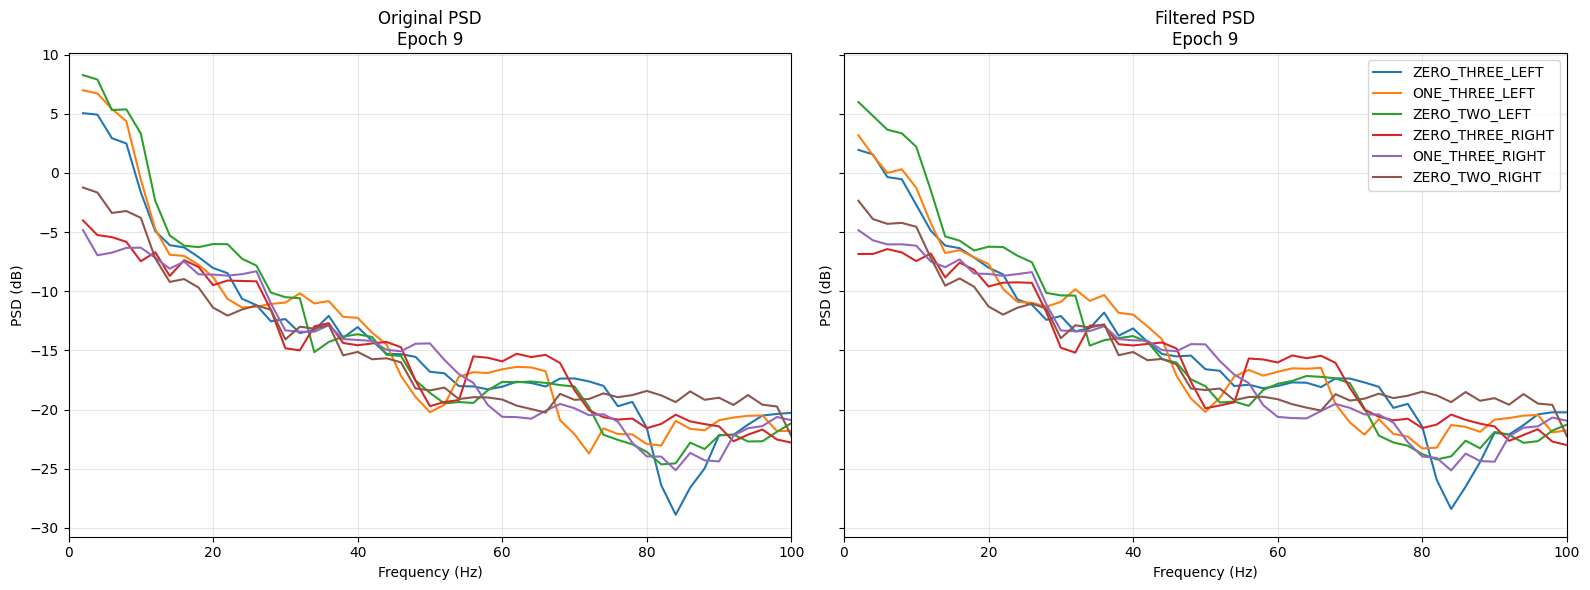

In [57]:
patient_name = 'PW_HK59'
channel_idx = 0
epoch_idx = 8

if not filter_segements:
    filtered_patients_epochs = patients_epochs

Visualise.plot_epoch_spectrogram_and_psd(
    signal_orig=patients_epochs[patient_name],
    signal_filt=filtered_patients_epochs[patient_name],
    patient_name=patient_name,
    epoch_idx=epoch_idx,
    channel_idx=channel_idx,
    save_path=fig_save_path,
    fig_name=f'spectrogram_psd_comparison_{patient_name}_ch{channel_idx}_epoch{epoch_idx}',
    show_fig=True
)

Visualise.plot_epoch_psd_comparison(
    patients_epochs[patient_name],
    filtered_patients_epochs[patient_name],
    epoch_idx,
    fix_chs_names=fix_chs_names
)

/home/orabem/gaitmod/gaitmod/viz.py:701: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
/home/orabem/gaitmod/gaitmod/viz.py:701: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
/home/orabem/gaitmod/gaitmod/viz.py:701: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
/home/orabem/gaitmod/gaitmod/viz.py:701: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
/home/orabem/gaitmod/gaitmod/viz.py:701: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  

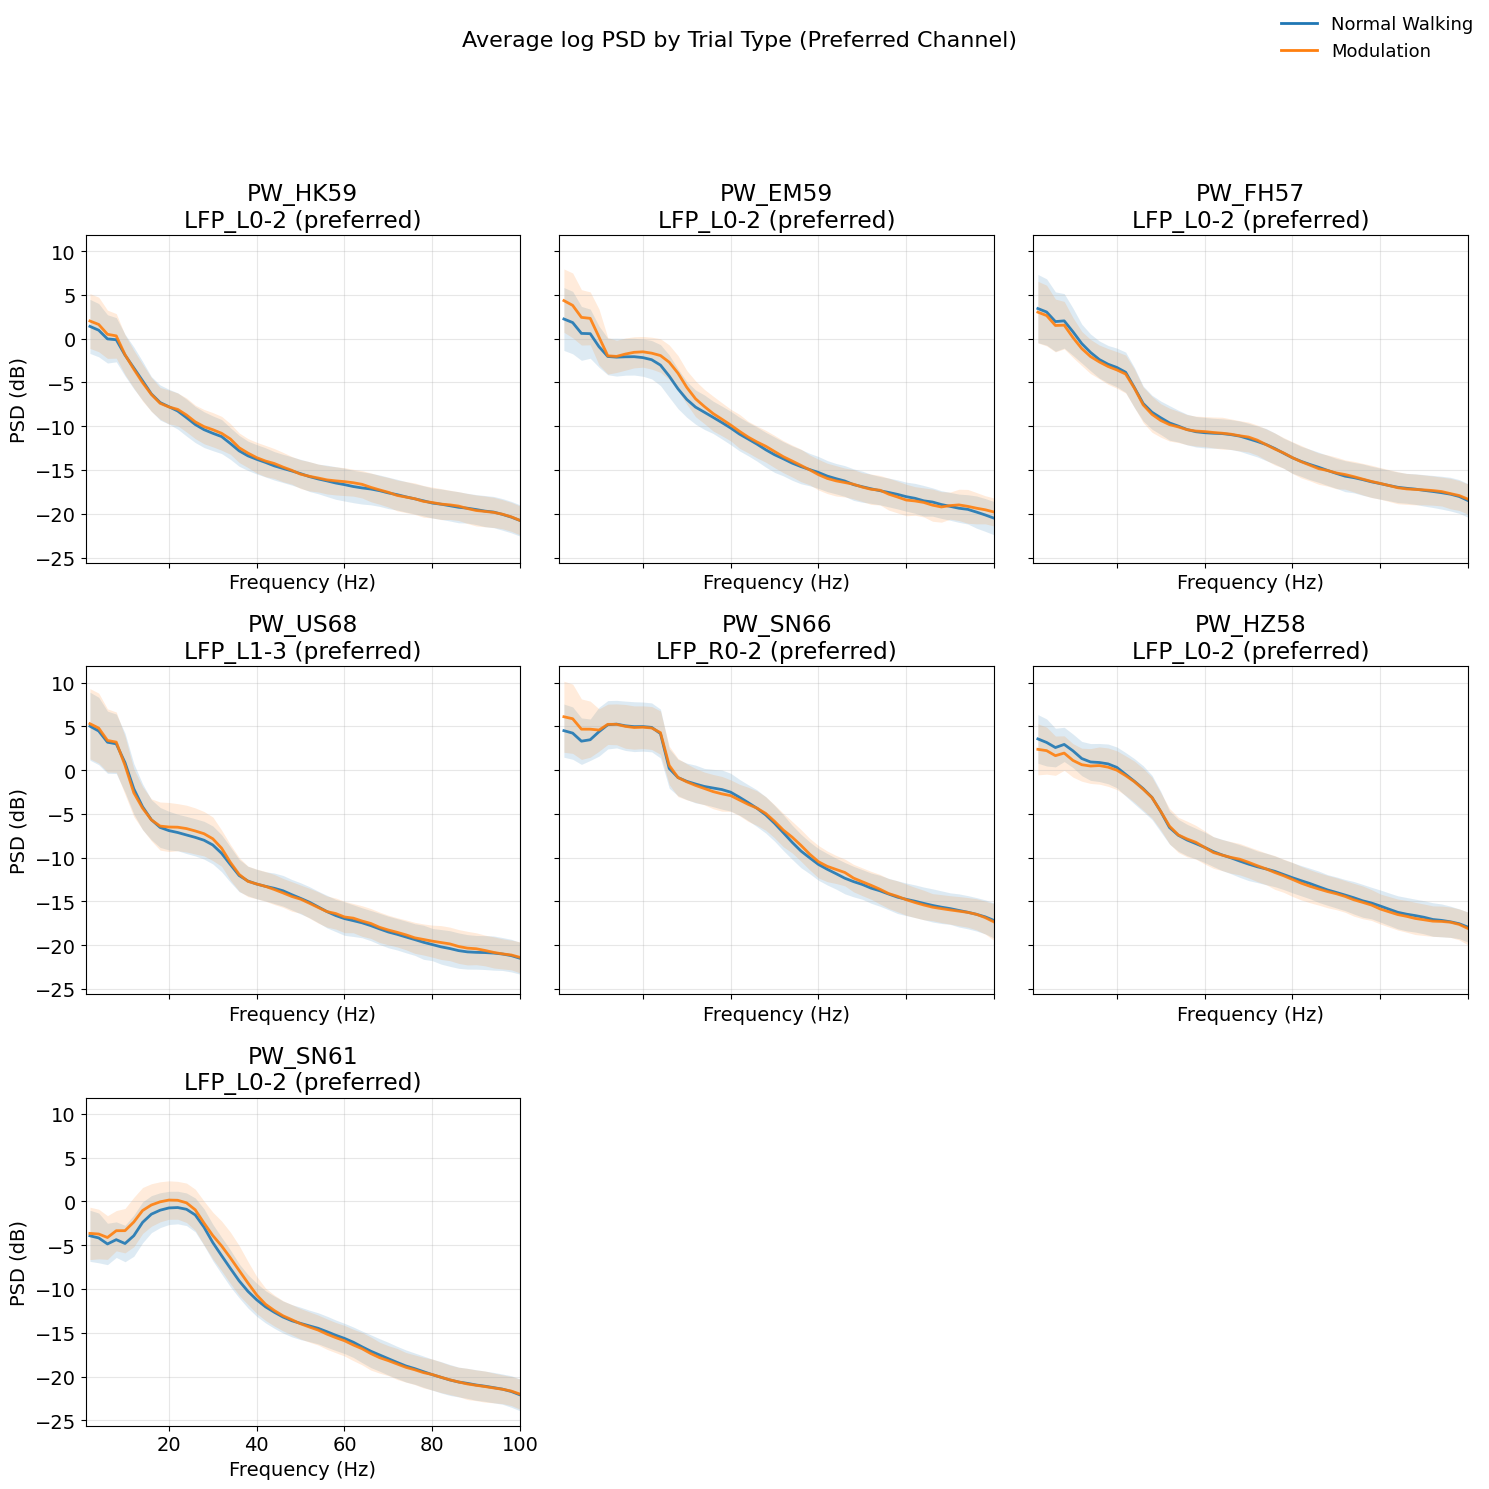

In [58]:
subject_preferred_channels = {
    "PW_EM59": "LFP_L0-2",
    "PW_FH57": "LFP_L0-2",
    "PW_HK59": "LFP_L0-2",
    "PW_HZ58": "LFP_L0-2",
    "PW_SN61": "LFP_L0-2",
    "PW_SN66": "LFP_R0-2",
    "PW_US68": "LFP_L1-3"
}
Visualise.plot_preferred_channel_trial_type_psd(
    patients_epochs,
    subject_preferred_channels,
    fmin=1.0,
    fmax=100.0,
    save_path=fig_save_path,
    fig_name="preferred_channel_trial_type_psd",
    colors={"normal_walking": "#1f77b4", "modulation": "#ff7f0e"}
)

In [54]:
# Visualise.plot_all_patients_trials(
#     subjects_lfp_data_dict,
#     filtered_patients_epochs,
#     sfreq=lfp_sfreq,
#     save_path=fig_save_path,
#     fig_name='lfp_data_all_patients_trials_colored_by_class_with_sessions',
#     subjects_session_trial_mapping=subjects_session_trial_mapping,
#     window_size=window_size,
#     overlap=overlap,
#     expand_transition=expand_transition,
#     sharex=True,
#     sharey=True,
# )

# Export epoched data

In [35]:
# print total number of epochs per class label
total_epochs_per_class = {}
for patient, epochs in patients_epochs.items():
    labels, counts = np.unique(epochs.events[:, -1], return_counts=True)
    for label, count in zip(labels, counts):
        if label not in total_epochs_per_class:
            total_epochs_per_class[label] = 0
        total_epochs_per_class[label] += count

print(f"Total epochs for both classes: {sum(total_epochs_per_class.values())}")
print(total_epochs_per_class)

# print ration of class labels
total_epochs = sum(total_epochs_per_class.values())
class_ratios = {label: count / total_epochs for label, count in total_epochs_per_class.items()}

print(class_ratios)

Total epochs for both classes: 6296
{0: 4150, 1: 2146}
{0: 0.659148665819568, 1: 0.340851334180432}


In [37]:
# createdirectory if not exists
os.makedirs('results/pickles', exist_ok=True)
# save_pkl(filtered_patients_epochs, 'results/pickles/filtered_patients_epochs.pickle')
# save_pkl(subjects_event_idx_dict, 'results/pickles/subjects_event_idx_dict.pickle')

save_pkl(patients_epochs, f'results/pickles/{total_epochs}epochs_patients_epochs.pickle')
save_pkl(subjects_event_idx_dict, f'results/pickles/{total_epochs}epochs_subjects_event_idx_dict.pickle')

In [38]:
from gaitmod.utils.utils import load_pkl
# patients_epochs = load_pkl('results/pickles/filtered_patients_epochs.pickle')
patients_epochs = load_pkl(f'results/pickles/{total_epochs}epochs_patients_epochs.pickle')

In [39]:
# print total number of epochs per class label
total_epochs_per_class = {}
for patient, epochs in patients_epochs.items():
    labels, counts = np.unique(epochs.events[:, -1], return_counts=True)
    for label, count in zip(labels, counts):
        if label not in total_epochs_per_class:
            total_epochs_per_class[label] = 0
        total_epochs_per_class[label] += count

print(f"Total epochs for both classes: {sum(total_epochs_per_class.values())}")
print(total_epochs_per_class)

# print ration of class labels
total_epochs = sum(total_epochs_per_class.values())
class_ratios = {label: count / total_epochs for label, count in total_epochs_per_class.items()}

print(class_ratios)

Total epochs for both classes: 6296
{0: 4150, 1: 2146}
{0: 0.659148665819568, 1: 0.340851334180432}


# Rule 1

- Remove the first trial of each session’s patient
- Remove very long trials (Can I just crop the end instead?, I need to see the videos)
- Remove trials with less than 4 modulation (overlapping) epochs (~ <1.75 seconds)

Use **mixed_window_policy = "keep_all” in segment_and_label_trials()**

Total epochs for both classes: 4646
{0: 2998, 1: 1648}
{0: 65%, 1: 35%}

# Rule 2: 
- Rule 1 + removed overlapped windows

Use **mixed_window_policy = "drop_all_mixed” in segment_and_label_trials()**

Total epochs for both classes: 3546
{0: 2320, 1: 1226}
{0: 0.65%, 1: 0.35%}

---

In [ ]:
# Improved: Visualize the distribution of trial lengths per subject using density curves\n# Inspired by the style in gaitmod/viz.py\n\ndef plot_trial_length_distributions(subjects_lfp_data_dict, lfp_sfreq=None, figsize=(12, 7), palette='tab10'):\n    """\n    Visualize the distribution of trial lengths per subject using density curves.\n    Parameters:\n        subjects_lfp_data_dict (dict): Dict of subject -> list of np.ndarray (trials, shape (n_channels, n_samples)).\n        lfp_sfreq (float, optional): If provided, converts samples to seconds.\n        figsize (tuple): Figure size.\n        palette (str or list): Color palette for subjects.\n    """\n    import matplotlib.pyplot as plt\n    import seaborn as sns\n    import numpy as np\n\n    plt.figure(figsize=figsize)\n    subjects = list(subjects_lfp_data_dict.keys())\n    palette = sns.color_palette(palette, len(subjects)) if isinstance(palette, str) else palette\n\n    for i, subject in enumerate(subjects):\n        trial_lengths = [trial.shape[1] for trial in subjects_lfp_data_dict[subject] if hasattr(trial, 'shape')]\n        if lfp_sfreq is not None:\n            trial_lengths = [length / lfp_sfreq for length in trial_lengths]\n        if len(trial_lengths) > 1:\n            sns.kdeplot(trial_lengths, label=str(subject), color=palette[i], fill=True, alpha=0.3, linewidth=2)\n        elif len(trial_lengths) == 1:\n            plt.scatter(trial_lengths, [0.01], label=str(subject), color=palette[i])\n\n    plt.xlabel('Trial Length' + (' (seconds)' if lfp_sfreq else ' (samples)'), fontsize=14)\n    plt.ylabel('Density', fontsize=14)\n    plt.title('Distribution of Trial Lengths per Subject', fontsize=16, fontweight='bold')\n    plt.legend(title='Subject', fontsize=12)\n    plt.grid(axis='y', linestyle='--', alpha=0.7)\n    plt.tight_layout()\n    plt.show()